
# sPHENIX TPC: direct Green-function convolution

This notebook follows the electrostatic calculation in the literal computational order

$$
G(x,x')
\;\longrightarrow\;
\text{QA of }G
\;\longrightarrow\;
\rho(x')
\;\longrightarrow\;
\Phi(x)
\;\longrightarrow\;
\mathbf E(x).
$$

Here

$$
x=(r,\phi,z)
$$

is the observation point and

$$
x'=(r',\phi',z')
$$

is the source point.

The TPC half-volume is treated explicitly as a **cylindrical annulus**:

$$
a<r<b,\qquad 0<z<L,\qquad \phi\equiv\phi+2\pi.
$$

The azimuthal coordinate is periodic. Every observation--source angular
difference is wrapped into the principal interval

$$
\Delta\phi
=
\operatorname{atan2}
\left[
\sin(\phi-\phi'),
\cos(\phi-\phi')
\right]
\in[-\pi,\pi).
$$

The Fourier basis is therefore evaluated with a seam-safe angular difference,

$$
\cos(m\Delta\phi),\qquad \sin(m\Delta\phi),
$$

so a source just below \(2\pi\) and an observation just above \(0\) are treated
as neighboring points, not as points separated by nearly \(2\pi\).

The essential difference from the faster modal notebook is that this notebook
first constructs and stores the sampled six-coordinate kernels

$$
G(r,\phi,z;r',\phi',z'),
$$

$$
K_r=-\frac{\partial G}{\partial r},
\qquad
K_\phi=-\frac{1}{r}\frac{\partial G}{\partial\phi},
\qquad
K_z=-\frac{\partial G}{\partial z},
$$

and then uses those exact stored arrays in the discrete convolution.

The Green arrays are therefore not only diagnostic output. They are the
numerical objects from which the potential and electric field are calculated.

By default the source is axisymmetric, all azimuthal modulation amplitudes are
zero, and only the \(m=0\) Fourier mode is retained automatically. Optional
\(\phi\) modulation is supported. QA is shown in the \(r\)-\(z\),
\(\phi\)-\(z\), and \(\phi\)-\(r\) planes.



## 1. Electrostatic equations

The perturbing potential produced by the positive-ion cloud satisfies

$$
\nabla^2\Phi(x)
=
-\frac{\rho(x)}{\epsilon_0}.
$$

The electric field is

$$
\mathbf E(x)
=
-\nabla\Phi(x).
$$

The TPC half-volume is modeled as a grounded coaxial cylindrical cavity,

$$
a<r<b,
\qquad
0<z<L,
\qquad
0\leq\phi<2\pi.
$$

The radial and longitudinal surfaces are grounded:

$$
\Phi(a,\phi,z)=\Phi(b,\phi,z)=0,
$$

$$
\Phi(r,\phi,0)=\Phi(r,\phi,L)=0.
$$

There is **no physical boundary at**
\(\phi=0\) or \(\phi=2\pi\). These coordinates label the same cylindrical seam:

$$
\Phi(r,\phi+2\pi,z)=\Phi(r,\phi,z),
$$

and likewise for the cylindrical field components:

$$
E_r(r,\phi+2\pi,z)=E_r(r,\phi,z),
$$

$$
E_\phi(r,\phi+2\pi,z)=E_\phi(r,\phi,z),
$$

$$
E_z(r,\phi+2\pi,z)=E_z(r,\phi,z).
$$

For sPHENIX we use

$$
a=20\ \mathrm{cm},
\qquad
b=75.911\ \mathrm{cm},
\qquad
L=102.325\ \mathrm{cm}.
$$

The ion source may begin at a radius different from \(a\), but this is only a
source edge. The physical inner electrostatic boundary remains at \(r=a\).


## 2. Green function

The Green function satisfies

$$
-\nabla_x^2G(x,x')
=
\frac{
\delta(r-r')
\delta(\phi-\phi')
\delta(z-z')
}{r},
$$

with the same grounded boundaries as the potential.

Once it is known,

$$
\Phi(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')G(x,x'),
$$

where

$$
dV'
=
r'\,dr'\,d\phi'\,dz'.
$$

The field is obtained from differentiated kernels,

$$
E_r(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_r(x,x'),
$$

$$
E_\phi(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_\phi(x,x'),
$$

$$
E_z(x)
=
\frac{1}{\epsilon_0}
\int dV'\,
\rho(x')K_z(x,x').
$$

This notebook evaluates the direct finite-cavity Fourier--Bessel--sine representation

$$
G(r,r',z,z',\phi,\phi')
=
\sum_{m=0}^{m_{\max}}
\sum_{n=1}^{N_r}
\sum_{l=1}^{N_z}
\frac{2-\delta_{m0}}{2\pi}
\cos[m(\phi-\phi')]
\frac{R_{mn}(r)R_{mn}(r')}{N_{mn}^2}
\frac{2}{L}
\frac{\sin(q_lz)\sin(q_lz')}
{k_{mn}^2+q_l^2}.
$$

This exact triple-sum form is a direct separation-of-variables solution of the finite grounded cavity. It is not claimed to be a verbatim displayed equation from Rossegger's thesis, but it solves the same Dirichlet boundary-value problem in the complete-mode limit.

In [1]:
import json, time
from pathlib import Path
from array import array

import numpy as np
import ROOT as root
from scipy import optimize, special
from numpy.polynomial.legendre import leggauss
from IPython.display import display, Image

root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetNumberContours(80)

EPSILON_0 = 8.8541878128e-12
CM_TO_M = 1e-2
M_TO_CM = 100.0

%jsroot on

Welcome to JupyROOT 6.30/06


In [2]:
# Geometry
A_CM, B_CM, L_CM = 20.0, 75.911, 102.325
SOURCE_R_MIN_CM, SOURCE_R_MAX_CM = 20.01, 75.911

# Charge model
RHO_REFERENCE_NC_PER_M3 = 20.0
K_EFF = 1.0
RADIAL_POWER_ALPHA = 1.5
M1_AMPLITUDE, M1_PHASE = 0.0, 0.0
M12_AMPLITUDE, M12_PHASE = 0.0, 0.0

# Real GEM source geometry and measured module gains
PAD_PLACEMENT_FILE = Path("TPC_pad_placement.txt")
GAIN_MAP_FILE = Path("dbb9e854-b14e-488e-9991-8f6f1962dffb.txt")
TPC_SIDE = 0                 # 0 = positive-z, 1 = negative-z
GAIN_METHOD = 1              # 1 = merged histograms, 2 = summed fits
MULTIPLY_CHARGE_BY_GAIN = True
NORMALIZE_GAIN_WEIGHTED_TOTAL = True

# Direct Green grids: moderate defaults to control memory
# Keep only two observation-phi bins for the dense direct kernel,
# but use 24 source-phi bins to resolve the 12 GEM sectors.
NR_OBS, NPHI_OBS, NZ_OBS = 40, 2, 40
NR_SRC, NPHI_SRC, NZ_SRC = 40, 24, 40

# Modal truncation
M_PHI_MAX = 12
N_RADIAL_MODES = 32
N_LONGITUDINAL_MODES = 32
AUTO_AXISYMMETRIC = False

# QA
DO_QA = True
DO_PHI_QA = True
DO_GAUSS_QA = True
DO_PERIODICITY_QA = True
PHI_SEAM_EPS = 1.0e-7
PHI_QA_NBINS = 72

# Outputs
GREEN_FILE = "sphenix_direct_green_kernels.root"
FIELD_FILE = "sphenix_direct_fields_3d.root"
GARFIELD_FILE = "sphenix_direct_garfield_field.root"
QA_DIR = Path("direct_green_qa")
QA_DIR.mkdir(exist_ok=True)

In [3]:
NR_OBS, NPHI_OBS, NZ_OBS = 16, 8, 16
NR_SRC, NPHI_SRC, NZ_SRC = 16, 8, 16

M_PHI_MAX = 12
N_RADIAL_MODES = 6
N_LONGITUDINAL_MODES = 6

AUTO_AXISYMMETRIC = False

## 3. Discrete source and observation grids

The Green function has six coordinates. On a grid it becomes

$$
G[i_r,i_\phi,i_z,j_r,j_\phi,j_z].
$$

The first three indices label observation points and the last three label source points.

If

$$
N_{\rm obs}
=
N_r^{\rm obs}N_\phi^{\rm obs}N_z^{\rm obs}
$$

and

$$
N_{\rm src}
=
N_r^{\rm src}N_\phi^{\rm src}N_z^{\rm src},
$$

then each dense kernel contains

$$
N_{\rm obs}N_{\rm src}
$$

floating-point values.

We store four arrays: $G$, $K_r$, $K_\phi$, and $K_z$. The notebook prints the memory estimate before constructing them.

In [4]:

a, b, L = A_CM*CM_TO_M, B_CM*CM_TO_M, L_CM*CM_TO_M
rs0, rs1 = SOURCE_R_MIN_CM*CM_TO_M, SOURCE_R_MAX_CM*CM_TO_M


def wrap_phi(phi):
    """
    Map any angle to [0, 2*pi).
    """
    return np.mod(phi, 2.0*np.pi)


def wrapped_delta_phi(phi_observation, phi_source):
    """
    Shortest signed angular separation on a cylinder.

    The returned value is in [-pi, pi).  Using this inside the
    Green-function calculation makes the periodic seam explicit.
    """
    delta = np.asarray(phi_observation) - np.asarray(phi_source)
    return np.arctan2(np.sin(delta), np.cos(delta))


phi_uniform = (
    abs(M1_AMPLITUDE) < 1e-15
    and abs(M12_AMPLITUDE) < 1e-15
)
M_EFFECTIVE = (
    0
    if AUTO_AXISYMMETRIC and phi_uniform
    else M_PHI_MAX
)

# Observation grid: annular cylindrical cells.
r_obs_edges = np.linspace(a, b, NR_OBS+1)
phi_obs_edges = np.linspace(0.0, 2.0*np.pi, NPHI_OBS+1)
z_obs_edges = np.linspace(0.0, L, NZ_OBS+1)

r_obs = 0.5*(r_obs_edges[:-1] + r_obs_edges[1:])
phi_obs = wrap_phi(
    0.5*(phi_obs_edges[:-1] + phi_obs_edges[1:])
)
z_obs = 0.5*(z_obs_edges[:-1] + z_obs_edges[1:])

# Source grid: annular cylindrical cells.
r_src_edges = np.linspace(rs0, rs1, NR_SRC+1)
phi_src_edges = np.linspace(0.0, 2.0*np.pi, NPHI_SRC+1)
z_src_edges = np.linspace(0.0, L, NZ_SRC+1)

r_src = 0.5*(r_src_edges[:-1] + r_src_edges[1:])
phi_src = wrap_phi(
    0.5*(phi_src_edges[:-1] + phi_src_edges[1:])
)
z_src = 0.5*(z_src_edges[:-1] + z_src_edges[1:])

# Exact cylindrical cell volumes:
# dV = 1/2 (r_hi^2-r_lo^2) dphi dz.
dV = (
    0.5*(r_src_edges[1:]**2-r_src_edges[:-1]**2)[:,None,None]
    * np.diff(phi_src_edges)[None,:,None]
    * np.diff(z_src_edges)[None,None,:]
)

NOBS = NR_OBS*NPHI_OBS*NZ_OBS
NSRC = NR_SRC*NPHI_SRC*NZ_SRC
mem = NOBS*NSRC*8/1024**2

# Exact volume of the annular source cylinder.
source_volume_exact = np.pi*(rs1**2-rs0**2)*L
source_volume_grid = np.sum(dV)
source_volume_relative_error = (
    source_volume_grid-source_volume_exact
)/source_volume_exact

print("Observation points:", NOBS)
print("Source points:", NSRC)
print("Memory per kernel:", mem, "MiB")
print("Four-kernel memory:", 4*mem, "MiB")
print("Effective m_max:", M_EFFECTIVE)
print()
print("Cylinder checks")
print("  phi coverage:", phi_obs_edges[0], "to", phi_obs_edges[-1])
print("  source grid volume [m^3]:", source_volume_grid)
print("  exact annular volume [m^3]:", source_volume_exact)
print("  relative volume error:", source_volume_relative_error)

assert np.isclose(
    phi_obs_edges[-1]-phi_obs_edges[0],
    2.0*np.pi,
    rtol=0.0,
    atol=1.0e-14,
)
assert np.isclose(
    source_volume_grid,
    source_volume_exact,
    rtol=1.0e-13,
    atol=1.0e-15,
)
assert np.all(phi_obs >= 0.0)
assert np.all(phi_obs < 2.0*np.pi)
assert np.all(phi_src >= 0.0)
assert np.all(phi_src < 2.0*np.pi)


Observation points: 2048
Source points: 2048
Memory per kernel: 32.0 MiB
Four-kernel memory: 128.0 MiB
Effective m_max: 12

Cylinder checks
  phi coverage: 0.0 to 6.283185307179586
  source grid volume [m^3]: 1.723712776445224
  exact annular volume [m^3]: 1.723712776445224
  relative volume error: 0.0


## 4. Radial eigenfunctions and allowed radial wave numbers

For a fixed azimuthal order $m$, the radial equation has Bessel solutions. We define

$$
R_m(k,r)
=
J_m(kr)Y_m(ka)
-
Y_m(kr)J_m(ka).
$$

This automatically gives

$$
R_m(k,a)=0.
$$

To make the same mode vanish at the outer field cage, we require

$$
R_m(k,b)=0.
$$

Therefore the allowed values of $k$ are roots of

$$
F_m(k)
=
J_m(kb)Y_m(ka)
-
Y_m(kb)J_m(ka).
$$

The roots are labeled $k_{mn}$, where $n$ counts radial modes. The normalization is

$$
N_{mn}^2
=
\int_a^b rR_{mn}^2(r)\,dr.
$$

In [5]:
def F(k,m):
    return special.jv(m,k*b)*special.yv(m,k*a)-special.yv(m,k*b)*special.jv(m,k*a)

def R(k,m,r):
    return special.jv(m,k*r)*special.yv(m,k*a)-special.yv(m,k*r)*special.jv(m,k*a)

def dR(k,m,r):
    return k*(special.jvp(m,k*r,1)*special.yv(m,k*a)-special.yvp(m,k*r,1)*special.jv(m,k*a))

def roots_for_m(m,nroot):
    roots=[]
    step=0.2*np.pi/(b-a)
    x=max(1e-6,0.1*np.pi/(b-a))
    fx=F(x,m)
    xmax=(nroot+m+25)*np.pi/(b-a)
    while x+step <= xmax and len(roots)<nroot:
        y=x+step
        fy=F(y,m)
        if np.isfinite(fx) and np.isfinite(fy) and fx*fy<0:
            rt=optimize.brentq(F,x,y,args=(m,),xtol=1e-13,rtol=1e-13)
            if not roots or abs(rt-roots[-1])>1e-9:
                roots.append(rt)
        x,fx=y,fy
    if len(roots)!=nroot:
        raise RuntimeError(f"m={m}: found {len(roots)} roots, requested {nroot}")
    return np.array(roots)

xg,wg=leggauss(160)
rr=0.5*(b-a)*xg+0.5*(b+a)
jac=0.5*(b-a)

k_modes={}
norms={}
for m in range(M_EFFECTIVE+1):
    k_modes[m]=roots_for_m(m,N_RADIAL_MODES)
    norms[m]=np.array([jac*np.sum(wg*rr*R(k,m,rr)**2) for k in k_modes[m]])
    print(m, max(abs(R(k,m,a)) for k in k_modes[m]), max(abs(R(k,m,b)) for k in k_modes[m]))

q_modes=np.arange(1,N_LONGITUDINAL_MODES+1)*np.pi/L

0 0.0 1.499494972634352e-14
1 0.0 2.270406085358445e-14
2 0.0 6.25888230132432e-15
3 0.0 9.5513874587283e-15
4 0.0 4.3021142204224816e-16
5 0.0 1.670105026496671e-14
6 0.0 8.128914208427318e-15
7 0.0 3.1086244689504383e-15
8 0.0 2.120108559197642e-13
9 0.0 5.4800781967845325e-14
10 0.0 2.754159205385631e-13
11 0.0 2.6978419498391304e-14
12 0.0 6.114542252649022e-12


## 5. Constructing the full Green-function and field-kernel arrays

This cell constructs four six-dimensional arrays:

$$
G(r,\phi,z;\,r',\phi',z'),
$$

$$
K_r(r,\phi,z;\,r',\phi',z'),
$$

$$
K_\phi(r,\phi,z;\,r',\phi',z'),
$$

and

$$
K_z(r,\phi,z;\,r',\phi',z').
$$

The first three coordinates,

$$
(r,\phi,z),
$$

describe the **observation point**, where the potential or electric field is evaluated.

The last three coordinates,

$$
(r',\phi',z'),
$$

describe the **source point**, where the charge is located.

All four arrays have the common shape

```python
shape = (
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
    NR_SRC,
    NPHI_SRC,
    NZ_SRC
)
```

The axis ordering is

```text
observation r,
observation phi,
observation z,
source r,
source phi,
source z
```

or, using compact index labels,

```text
R P Z S T U
```

where:

- `R` labels the observation radius $r$;
- `P` labels the observation angle $\phi$;
- `Z` labels the observation coordinate $z$;
- `S` labels the source radius $r'$;
- `T` labels the source angle $\phi'$;
- `U` labels the source coordinate $z'$.

For example,

```python
G[ir, ip, iz, jr, jp, jz]
```

is the Green-function value connecting the source point

$$
(r'_{jr},\phi'_{jp},z'_{jz})
$$

to the observation point

$$
(r_{ir},\phi_{ip},z_{iz}).
$$

### 5.1 Allocating the kernel arrays

The code begins by defining the common six-dimensional array shape:

```python
shape = (
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
    NR_SRC,
    NPHI_SRC,
    NZ_SRC
)
```

The Green-function and electric-field kernel arrays are then initialized:

```python
G  = np.zeros(shape)
Kr = np.zeros(shape)
Kp = np.zeros(shape)
Kz = np.zeros(shape)
```

Initially, every array element is zero.

The arrays are filled by summing the contributions from all retained modes:

$$
m=0,\ldots,m_{\max},
$$

$$
n=1,\ldots,N_{\mathrm{radial}},
$$

and

$$
\ell=1,\ldots,N_{\mathrm{longitudinal}}.
$$

The code uses `+=` because every mode contributes one term to the total Green function and field kernels.

Schematically,

$$
G
=
\sum_m
\sum_n
\sum_\ell
G_{mn\ell},
$$

and similarly for $K_r$, $K_\phi$, and $K_z$.


### 5.2 Wrapped angular difference between observation and source points

The angular part of the Green function depends on the periodic separation

$$
\Delta\phi
=
\phi-\phi'.
$$

Because the TPC is a cylinder, the relevant separation is the shortest signed
distance around the circle:

$$
\Delta\phi_{\rm wrap}
=
\operatorname{atan2}
\left[
\sin(\phi-\phi'),
\cos(\phi-\phi')
\right].
$$

The code constructs all wrapped observation--source differences simultaneously:

```python
dphi = wrapped_delta_phi(
    phi_obs[:, None],
    phi_src[None, :],
)
```

The result is restricted to

$$
-\pi\leq\Delta\phi_{\rm wrap}<\pi.
$$

For example, an observation at \(0.01\) rad and a source at
\(2\pi-0.01\) rad have

$$
\Delta\phi_{\rm wrap}=0.02\ {\rm rad},
$$

not approximately \(-2\pi\).

The Fourier basis then uses

$$
\cos(m\Delta\phi_{\rm wrap})
$$

and

$$
\sin(m\Delta\phi_{\rm wrap}).
$$

Mathematically, integer Fourier harmonics are already \(2\pi\)-periodic.
The explicit wrapping is retained here to make the cylindrical topology
unambiguous and to support direct seam QA.


### 5.3 Loop over the azimuthal order m

The outer loop is

```python
for m in range(M_EFFECTIVE + 1):
```

For each azimuthal order $m$, the angular basis function is

$$
A_m(\phi,\phi')
=
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi-\phi')\right].
$$

The normalization factor is calculated as

```python
pref = (2.0 if m > 0 else 1.0) / (2*np.pi)
```

Therefore,

$$
\mathrm{pref}
=
\begin{cases}
\dfrac{1}{2\pi}, & m=0, \\[6pt]
\dfrac{1}{\pi}, & m>0.
\end{cases}
$$

The complete angular matrix is

```python
A = pref * np.cos(m*dphi)
```

with shape

```python
A.shape == (NPHI_OBS, NPHI_SRC)
```

and elements

$$
A_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi_P-\phi'_T)\right].
$$

For $m=0$, the angular factor is constant:

$$
A_0
=
\frac{1}{2\pi}.
$$

For $m>0$, the angular dependence oscillates with the relative angle $\phi-\phi'$.

### 5.4 Angular derivative for the Kphi kernel

The azimuthal electric-field kernel is defined as

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi}.
$$

The angular part of the Green function contains

$$
\cos\left[m(\phi-\phi')\right].
$$

Its negative derivative with respect to the observation angle $\phi$ is

$$
-\frac{\partial}{\partial\phi}
\cos\left[m(\phi-\phi')\right]
=
m\sin\left[m(\phi-\phi')\right].
$$

The code therefore constructs the differentiated angular matrix as

```python
Ap = (
    pref * m * np.sin(m*dphi)
    if m > 0
    else np.zeros_like(A)
)
```

Its elements are

$$
Ap_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
m\sin\left[m(\phi_P-\phi'_T)\right].
$$

For the axisymmetric mode $m=0$,

```python
Ap = np.zeros_like(A)
```

because

$$
\frac{\partial A_0}{\partial\phi}
=
0.
$$

Therefore, the $m=0$ mode gives no contribution to the azimuthal field kernel:

$$
K_\phi^{(m=0)}
=
0.
$$

### 5.5 Loop over the radial modes

The next loop is

```python
for n, k in enumerate(k_modes[m]):
```

Here:

- `n` is the radial-mode index;
- `k` is the corresponding radial eigenvalue $k_{mn}$.

For each radial mode, the radial basis function is evaluated at all observation radii:

```python
ro = R(k, m, r_obs)
```

This array represents

$$
R_{mn}(r).
$$

The radial derivative is evaluated as

```python
dro = dR(k, m, r_obs)
```

and represents

$$
R'_{mn}(r)
=
\frac{\partial R_{mn}(r)}{\partial r}.
$$

The radial basis function is also evaluated at all source radii:

```python
rs = R(k, m, r_src)
```

which represents

$$
R_{mn}(r').
$$

The array shapes are

```python
ro.shape  == (NR_OBS,)
dro.shape == (NR_OBS,)
rs.shape  == (NR_SRC,)
```

Thus, `ro` and `dro` depend only on the observation radius, while `rs` depends only on the source radius.

### 5.6 Radial observation-source matrices

The radial contribution to the scalar Green function is constructed as

```python
RG = np.outer(ro, rs) / norms[m][n]
```

The operation

```python
np.outer(ro, rs)
```

creates every observation-source product

$$
R_{mn}(r_R)\,R_{mn}(r'_S).
$$

Therefore,

```python
RG.shape == (NR_OBS, NR_SRC)
```

and its elements are

$$
RG_{RS}
=
\frac{
R_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

Here,

```python
norms[m][n]
```

contains the radial normalization

$$
N_{mn}^{2}
=
\int_a^b
r\,R_{mn}^{2}(r)\,dr.
$$

The radial factor for the radial electric-field kernel is

```python
RR = -np.outer(dro, rs) / norms[m][n]
```

with elements

$$
RR_{RS}
=
-
\frac{
R'_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

The minus sign appears because the radial field kernel is defined as

$$
K_r
=
-\frac{\partial G}{\partial r}.
$$

### 5.7 Loop over the longitudinal modes

The innermost loop is

```python
for q in q_modes:
```

The longitudinal wave numbers are

$$
q_\ell
=
\frac{\ell\pi}{L}.
$$

For each pair of radial and longitudinal modes, the denominator is

```python
den = k*k + q*q
```

which represents the Laplacian eigenvalue

$$
\lambda_{mn\ell}
=
k_{mn}^{2}
+
q_\ell^{2}.
$$

The longitudinal Green-function matrix is constructed as

```python
Z = (
    (2/L)
    * np.outer(
        np.sin(q*z_obs),
        np.sin(q*z_src)
    )
    / den
)
```

Its elements are

$$
Z_{ZU}
=
\frac{2}{L}
\frac{
\sin(q_\ell z_Z)\,
\sin(q_\ell z'_U)
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

The matrix shape is

```python
Z.shape == (NZ_OBS, NZ_SRC)
```

so `Z` connects every observation coordinate $z_Z$ to every source coordinate $z'_U$.

### 5.8 Longitudinal derivative for the Kz kernel

The longitudinal electric-field kernel is defined as

$$
K_z
=
-\frac{\partial G}{\partial z}.
$$

Using

$$
\frac{\partial}{\partial z}
\sin(q_\ell z)
=
q_\ell\cos(q_\ell z),
$$

we obtain

$$
-\frac{\partial}{\partial z}
\left[
\frac{2}{L}
\frac{
\sin(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}
\right]
=
-\frac{2}{L}
\frac{
q_\ell\cos(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

The code evaluates this expression as

```python
ZZ = (
    -(2/L)
    * np.outer(
        q*np.cos(q*z_obs),
        np.sin(q*z_src)
    )
    / den
)
```

The shape is

```python
ZZ.shape == (NZ_OBS, NZ_SRC)
```

The matrix `ZZ` therefore contains the observation-side longitudinal derivative of `Z`.

### 5.9 Understanding np.einsum

The scalar Green function is accumulated using

```python
G += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

The input index labels are

```text
RS, PT, ZU
```

This means:

- `RG` has indices `R,S`;
- `A` has indices `P,T`;
- `Z` has indices `Z,U`.

The output ordering is

```text
RPZSTU
```

Therefore, NumPy constructs a six-dimensional array with elements

$$
\mathrm{output}_{RPZSTU}
=
RG_{RS}\,
A_{PT}\,
Z_{ZU}.
$$

The indices correspond to

```text
R : observation radius
P : observation azimuth
Z : observation longitudinal coordinate
S : source radius
T : source azimuth
U : source longitudinal coordinate
```

Thus,

```python
np.einsum("RS,PT,ZU->RPZSTU", RG, A, Z)
```

constructs

$$
RG(r,r')\,
A(\phi,\phi')\,
Z(z,z')
$$

for every combination of

$$
(r,\phi,z,r',\phi',z').
$$

### 5.10 Why this einsum does not perform a summation

In Einstein summation notation, an index is summed over when it appears in the inputs but is absent from the output.

Here, the index structure is

```text
RS, PT, ZU -> RPZSTU
```

Every input index also appears in the output.

Therefore, this `einsum` does not sum over any array index.

Instead, it constructs the multidimensional outer product

$$
(R,S)
\otimes
(P,T)
\otimes
(Z,U).
$$

The modal summation is performed by the Python loops

```python
for m ...
    for n ...
        for q ...
```

and by the accumulation operation

```python
G += ...
```

Thus:

- `np.einsum` constructs one complete six-dimensional mode contribution;
- `+=` accumulates the contributions from all modes.

### 5.11 Small example of the same einsum operation

Suppose the input arrays have shapes

```python
RG.shape == (2, 3)
A.shape  == (4, 5)
Z.shape  == (6, 7)
```

Then

```python
out = np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z
)
```

has shape

```python
out.shape == (2, 4, 6, 3, 5, 7)
```

For example,

```python
out[1, 2, 4, 0, 3, 6]
```

is equal to

```python
RG[1, 0] * A[2, 3] * Z[4, 6]
```

In the Green-function calculation, this corresponds to

$$
G(r_1,\phi_2,z_4;\,r'_0,\phi'_3,z'_6).
$$

This element receives the product of:

- the radial response between $r_1$ and $r'_0$;
- the angular response between $\phi_2$ and $\phi'_3$;
- the longitudinal response between $z_4$ and $z'_6$.

### 5.12 Constructing the scalar Green function

The scalar Green function is accumulated using

```python
G += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

For one mode combination $(m,n,\ell)$, this adds

$$
\frac{
R_{mn}(r)\,R_{mn}(r')
}{
N_{mn}^{2}
}
\,
\frac{2-\delta_{m0}}{2\pi}
\cos\left[m(\phi-\phi')\right]
\,
\frac{2}{L}
\frac{
\sin(q_\ell z)\sin(q_\ell z')
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

After all loops are complete,

$$
G(r,\phi,z;\,r',\phi',z')
=
\sum_m
\sum_n
\sum_\ell
G_{mn\ell}(r,\phi,z;\,r',\phi',z').
$$

The resulting array contains the scalar response between every sampled source point and every sampled observation point.

### 5.13 Constructing the radial field kernel

The radial field kernel is accumulated using

```python
Kr += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RR,
    A,
    Z,
    optimize=True
)
```

The matrix `RR` contains the observation-side radial derivative:

$$
RR_{RS}
=
-
\frac{
R'_{mn}(r_R)\,R_{mn}(r'_S)
}{
N_{mn}^{2}
}.
$$

Therefore,

$$
K_r(r,\phi,z;\,r',\phi',z')
=
-\sum_{m,n,\ell}
\frac{
R'_{mn}(r)\,R_{mn}(r')
}{
N_{mn}^{2}
}
A_m(\phi,\phi')
Z_{mn\ell}(z,z').
$$

The angular and longitudinal factors are unchanged, while the radial basis at the observation point is differentiated.

This implements

$$
K_r
=
-\frac{\partial G}{\partial r}.
$$

### 5.14 Constructing the azimuthal field kernel

The azimuthal field kernel is accumulated using

```python
Kp += np.einsum(
    "R,RS,PT,ZU->RPZSTU",
    1/r_obs,
    RG,
    Ap,
    Z,
    optimize=True
)
```

The input index labels have the following meaning:

```text
R   : inverse observation radius, 1/r
RS  : radial observation-source matrix
PT  : differentiated angular matrix
ZU  : longitudinal observation-source matrix
```

The resulting elements are

$$
(K_\phi)_{RPZSTU}
=
\frac{1}{r_R}
RG_{RS}\,
Ap_{PT}\,
Z_{ZU}.
$$

The differentiated angular matrix is

$$
Ap_{PT}
=
\frac{2-\delta_{m0}}{2\pi}
m\sin\left[m(\phi_P-\phi'_T)\right].
$$

This implements

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi}.
$$

For the axisymmetric mode $m=0$,

```python
Ap = 0
```

so the corresponding contribution to $K_\phi$ is zero.

### 5.15 Constructing the longitudinal field kernel

The longitudinal field kernel is accumulated using

```python
Kz += np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    ZZ,
    optimize=True
)
```

This operation is identical to the scalar Green-function construction, except that the longitudinal matrix `Z` is replaced by its derivative `ZZ`.

The differentiated longitudinal matrix is

$$
ZZ_{ZU}
=
-\frac{2}{L}
\frac{
q_\ell\cos(q_\ell z_Z)\sin(q_\ell z'_U)
}{
k_{mn}^{2}+q_\ell^{2}
}.
$$

Therefore,

$$
K_z(r,\phi,z;\,r',\phi',z')
=
-\frac{\partial G}{\partial z}.
$$

Only the observation-side longitudinal basis is differentiated.

### 5.16 Role of optimize=True

Each `einsum` call includes

```python
optimize=True
```

This option asks NumPy to choose an efficient internal evaluation strategy.

For example,

```python
np.einsum(
    "RS,PT,ZU->RPZSTU",
    RG,
    A,
    Z,
    optimize=True
)
```

contains no contracted indices, so mathematically it is a multidimensional outer product.

The `optimize=True` option may improve the order of internal operations and memory handling, but it does not change the result.

### 5.17 Interpretation of one loop iteration

For one specific mode combination

$$
(m,n,\ell),
$$

the code performs the following steps:

1. evaluates the angular response for all $(\phi,\phi')$ pairs;
2. evaluates the radial response for all $(r,r')$ pairs;
3. evaluates the longitudinal response for all $(z,z')$ pairs;
4. evaluates the radial, azimuthal, and longitudinal derivatives;
5. constructs the complete six-dimensional source-response contribution;
6. adds this contribution to the total arrays.

The nested loops implement the modal sum

$$
\sum_m
\sum_n
\sum_\ell.
$$

The `einsum` operation constructs the six-coordinate contribution associated with one term in this sum.

Schematically,

$$
\text{one mode}
\longrightarrow
\text{radial factor}
\times
\text{angular factor}
\times
\text{longitudinal factor}
\longrightarrow
\text{six-dimensional contribution}.
$$

### 5.18 Arrays available after this cell

After all modal loops are complete,

```python
G
```

contains the scalar Green function

$$
G(r,\phi,z;\,r',\phi',z'),
$$

```python
Kr
```

contains the radial field kernel

$$
K_r
=
-\frac{\partial G}{\partial r},
$$

```python
Kp
```

contains the azimuthal field kernel

$$
K_\phi
=
-\frac{1}{r}
\frac{\partial G}{\partial\phi},
$$

and

```python
Kz
```

contains the longitudinal field kernel

$$
K_z
=
-\frac{\partial G}{\partial z}.
$$

At this stage, no charge-density distribution has been introduced.

The arrays describe the geometry response to a unit source placed at every sampled source position.

For a source voxel $j$, the charge is

$$
\Delta Q_j
=
\rho_j\,\Delta V_j.
$$

The electrostatic potential at observation point $i$ is then

$$
\Phi_i
=
\frac{1}{\epsilon_0}
\sum_j
G_{ij}\,\Delta Q_j.
$$

The electric-field components are

$$
E_{r,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{r,ij}\,\Delta Q_j,
$$

$$
E_{\phi,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{\phi,ij}\,\Delta Q_j,
$$

and

$$
E_{z,i}
=
\frac{1}{\epsilon_0}
\sum_j
K_{z,ij}\,\Delta Q_j.
$$

The complete calculation sequence is

$$
\text{mode functions}
\longrightarrow
G,\ K_r,\ K_\phi,\ K_z
\longrightarrow
\rho\,\Delta V
\longrightarrow
\Phi,\ E_r,\ E_\phi,\ E_z.
$$

In [6]:
shape=(NR_OBS,NPHI_OBS,NZ_OBS,NR_SRC,NPHI_SRC,NZ_SRC)
G=np.zeros(shape)
Kr=np.zeros(shape)
Kp=np.zeros(shape)
Kz=np.zeros(shape)

dphi = wrapped_delta_phi(
    phi_obs[:, None],
    phi_src[None, :],
)
assert np.all(dphi >= -np.pi-1e-14)
assert np.all(dphi < np.pi+1e-14)
t0=time.time()

for m in range(M_EFFECTIVE+1):
    pref=(2.0 if m>0 else 1.0)/(2*np.pi)
    A=pref*np.cos(m*dphi)
    Ap=pref*m*np.sin(m*dphi) if m>0 else np.zeros_like(A)

    for n,k in enumerate(k_modes[m]):
        ro=R(k,m,r_obs); dro=dR(k,m,r_obs); rs=R(k,m,r_src)
        RG=np.outer(ro,rs)/norms[m][n]
        RR=-np.outer(dro,rs)/norms[m][n]

        for q in q_modes:
            den=k*k+q*q
            Z=(2/L)*np.outer(np.sin(q*z_obs),np.sin(q*z_src))/den
            ZZ=-(2/L)*np.outer(q*np.cos(q*z_obs),np.sin(q*z_src))/den

            G += np.einsum("RS,PT,ZU->RPZSTU",RG,A,Z,optimize=True)
            Kr += np.einsum("RS,PT,ZU->RPZSTU",RR,A,Z,optimize=True)
            Kp += np.einsum("R,RS,PT,ZU->RPZSTU",1/r_obs,RG,Ap,Z,optimize=True)
            Kz += np.einsum("RS,PT,ZU->RPZSTU",RG,A,ZZ,optimize=True)

print("Kernel build time:",time.time()-t0,"s")
print("Kernel shape:",G.shape)

Kernel build time: 32.900689125061035 s
Kernel shape: (16, 8, 16, 16, 8, 16)



## 6. Green-function QA before introducing the source

Before applying a charge-density distribution, we test the geometry-only Green function and electric-field kernels.

These tests verify:

1. the boundary conditions;
2. electrostatic reciprocity;
3. the analytical derivatives used to construct the field kernels;
4. the spatial response to a fixed point source.

---


### 6.1 Boundary-condition test

The scalar Green function must vanish whenever the observation point lies on a grounded boundary:

$$
G(\mathbf{x},\mathbf{x}') = 0,
\qquad
\mathbf{x} \in \partial\Omega.
$$

For the cylindrical TPC geometry, this includes the radial boundaries

$$
r=a,
\qquad
r=b,
$$

and the longitudinal boundaries

$$
z=0,
\qquad
z=L.
$$

Numerically, we evaluate the maximum absolute Green-function value on each boundary:

```python
max_abs_G_rmin = np.max(np.abs(G_at_rmin))
max_abs_G_rmax = np.max(np.abs(G_at_rmax))
max_abs_G_zmin = np.max(np.abs(G_at_zmin))
max_abs_G_zmax = np.max(np.abs(G_at_zmax))
````

For a sufficiently converged modal expansion, all four values should be close to zero.

---



### 6.2 Reciprocity test

Electrostatic reciprocity requires

$$
G(\mathbf{x},\mathbf{x}') = G(\mathbf{x}',\mathbf{x}).
$$

In array notation, this corresponds to exchanging the observation and source coordinates:

$$
(r,\phi,z)
\longleftrightarrow
(r',\phi',z').
$$

For equal observation and source grids, the transposed Green-function array is

```python
G_reciprocal = np.transpose(G, (3, 4, 5, 0, 1, 2))
```

The reciprocity residual is then

```python
reciprocity_residual = G - G_reciprocal
```

A useful relative measure is

$$
\epsilon_{\mathrm{rec}}= \frac{
\max\left|G(\mathbf{x},\mathbf{x}') - G(\mathbf{x}',\mathbf{x})\right|
}{
\max\left|G(\mathbf{x},\mathbf{x}')\right|
}.
$$

Numerically:

```python
reciprocity_error = (
    np.max(np.abs(reciprocity_residual))
    / np.max(np.abs(G))
)
```

This quantity should decrease as more radial, azimuthal, and longitudinal modes are retained.

---


In [7]:

def green_point(r,p,z,rp,pp,zp):
    """
    Pointwise Green function and cylindrical field kernels.

    Both angles are mapped to the periodic cylinder and the angular
    separation is explicitly wrapped into [-pi, pi).
    """
    p = float(wrap_phi(p))
    pp = float(wrap_phi(pp))
    dphi = float(wrapped_delta_phi(p, pp))

    g = kr = kp = kz = 0.0

    for m in range(M_EFFECTIVE+1):
        pref = (2.0 if m>0 else 1.0)/(2*np.pi)
        c = np.cos(m*dphi)
        s = np.sin(m*dphi)

        for n,k in enumerate(k_modes[m]):
            ro = R(k,m,r)
            dro = dR(k,m,r)
            rs = R(k,m,rp)
            norm = norms[m][n]

            for q in q_modes:
                den = k*k+q*q
                zz = (2/L)*np.sin(q*z)*np.sin(q*zp)/den

                common = pref*rs/norm

                g += common*ro*c*zz
                kr += -common*dro*c*zz

                if m > 0:
                    kp += (
                        common
                        * (m/r)
                        * ro
                        * s
                        * zz
                    )

                kz += (
                    common
                    * ro
                    * c
                    * (
                        -(2/L)
                        * q*np.cos(q*z)
                        * np.sin(q*zp)
                        / den
                    )
                )

    return g,kr,kp,kz



### 6.3 Explicit proof of cylindrical \(\phi\) periodicity

The TPC has no boundary at the azimuthal seam. Therefore the pointwise kernels
must obey

$$
G(r,\phi+2\pi,z;r',\phi',z')
=
G(r,\phi,z;r',\phi',z'),
$$

and likewise for \(K_r\), \(K_\phi\), and \(K_z\).

We test periodicity in three complementary ways:

1. shift the observation angle by \(2\pi\);
2. shift the source angle by \(2\pi\);
3. place the source and observation on opposite sides of the
   \(0/2\pi\) seam and compare with an equivalent pair away from the seam.

The third test proves that a pair separated by a small angle across the seam
is treated identically to a pair with the same local separation elsewhere on
the cylinder.


In [8]:

if DO_PERIODICITY_QA:
    periodic_obs = (0.52, 0.37, 0.61)
    periodic_src = (0.43, 1.91, 0.37)

    base = np.array(
        green_point(
            *periodic_obs,
            *periodic_src,
        ),
        dtype=float,
    )

    obs_shifted = np.array(
        green_point(
            periodic_obs[0],
            periodic_obs[1] + 2.0*np.pi,
            periodic_obs[2],
            *periodic_src,
        ),
        dtype=float,
    )

    src_shifted = np.array(
        green_point(
            *periodic_obs,
            periodic_src[0],
            periodic_src[1] - 2.0*np.pi,
            periodic_src[2],
        ),
        dtype=float,
    )

    obs_periodicity_residual = obs_shifted - base
    src_periodicity_residual = src_shifted - base

    eps = PHI_SEAM_EPS

    # Same local angular separation, once across the seam and once away
    # from it.
    seam_pair = np.array(
        green_point(
            0.52,
            eps,
            0.61,
            0.43,
            2.0*np.pi-eps,
            0.37,
        ),
        dtype=float,
    )

    ordinary_pair = np.array(
        green_point(
            0.52,
            1.0+eps,
            0.61,
            0.43,
            1.0-eps,
            0.37,
        ),
        dtype=float,
    )

    seam_residual = seam_pair - ordinary_pair

    labels = ["G", "Kr", "Kphi", "Kz"]

    print("Wrapped angular differences")
    print(
        "  seam pair:",
        wrapped_delta_phi(eps, 2.0*np.pi-eps),
    )
    print(
        "  ordinary pair:",
        wrapped_delta_phi(1.0+eps, 1.0-eps),
    )
    print()

    for i,label in enumerate(labels):
        scale = max(abs(base[i]), abs(seam_pair[i]), 1.0e-30)

        print(
            f"{label:5s}: "
            f"obs +2pi residual={obs_periodicity_residual[i]: .6e}, "
            f"src -2pi residual={src_periodicity_residual[i]: .6e}, "
            f"seam residual={seam_residual[i]: .6e}, "
            f"relative seam residual={abs(seam_residual[i])/scale:.3e}"
        )

    assert np.allclose(
        obs_shifted,
        base,
        rtol=1.0e-12,
        atol=1.0e-14,
    )

    assert np.allclose(
        src_shifted,
        base,
        rtol=1.0e-12,
        atol=1.0e-14,
    )

    assert np.allclose(
        seam_pair,
        ordinary_pair,
        rtol=1.0e-10,
        atol=1.0e-13,
    )

    print()
    print("Periodic-cylinder seam tests passed.")


Wrapped angular differences
  seam pair: 2.00000000805792e-07
  ordinary pair: 2.0000000000575113e-07

G    : obs +2pi residual= 1.387779e-17, src -2pi residual= 0.000000e+00, seam residual= 0.000000e+00, relative seam residual=0.000e+00
Kr   : obs +2pi residual= 3.469447e-16, src -2pi residual= 0.000000e+00, seam residual= 0.000000e+00, relative seam residual=0.000e+00
Kphi : obs +2pi residual=-1.387779e-17, src -2pi residual= 0.000000e+00, seam residual=-2.524394e-16, relative seam residual=7.640e-15
Kz   : obs +2pi residual= 6.938894e-17, src -2pi residual= 0.000000e+00, seam residual= 0.000000e+00, relative seam residual=0.000e+00

Periodic-cylinder seam tests passed.



### 6.4 Continuous scan across the \(0/2\pi\) seam

A fixed source is placed close to the seam and the observation angle is scanned
through an interval that crosses \(2\pi\). The plotted coordinate is unwrapped
for readability, while every kernel evaluation uses the wrapped cylindrical
angle internally.

A discontinuity at the seam would indicate an incorrect non-periodic
implementation.


In [9]:
import matplotlib.pyplot as plt

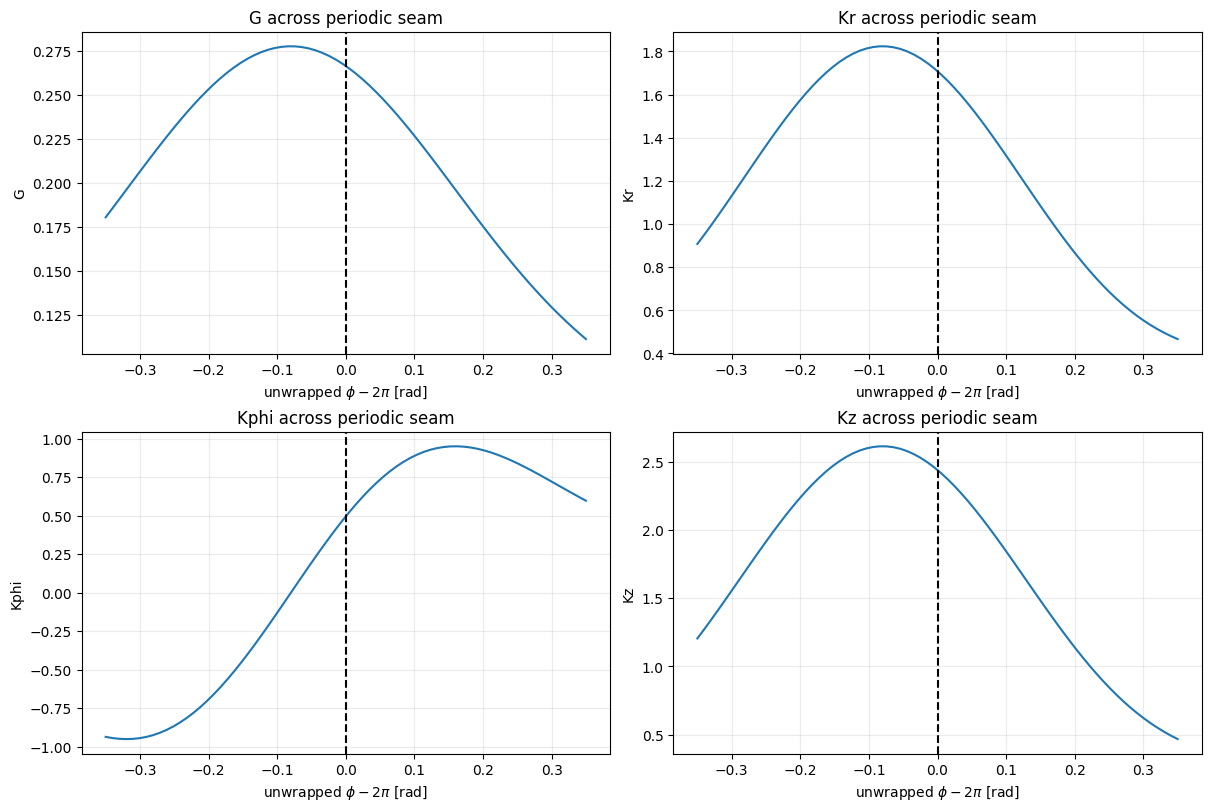

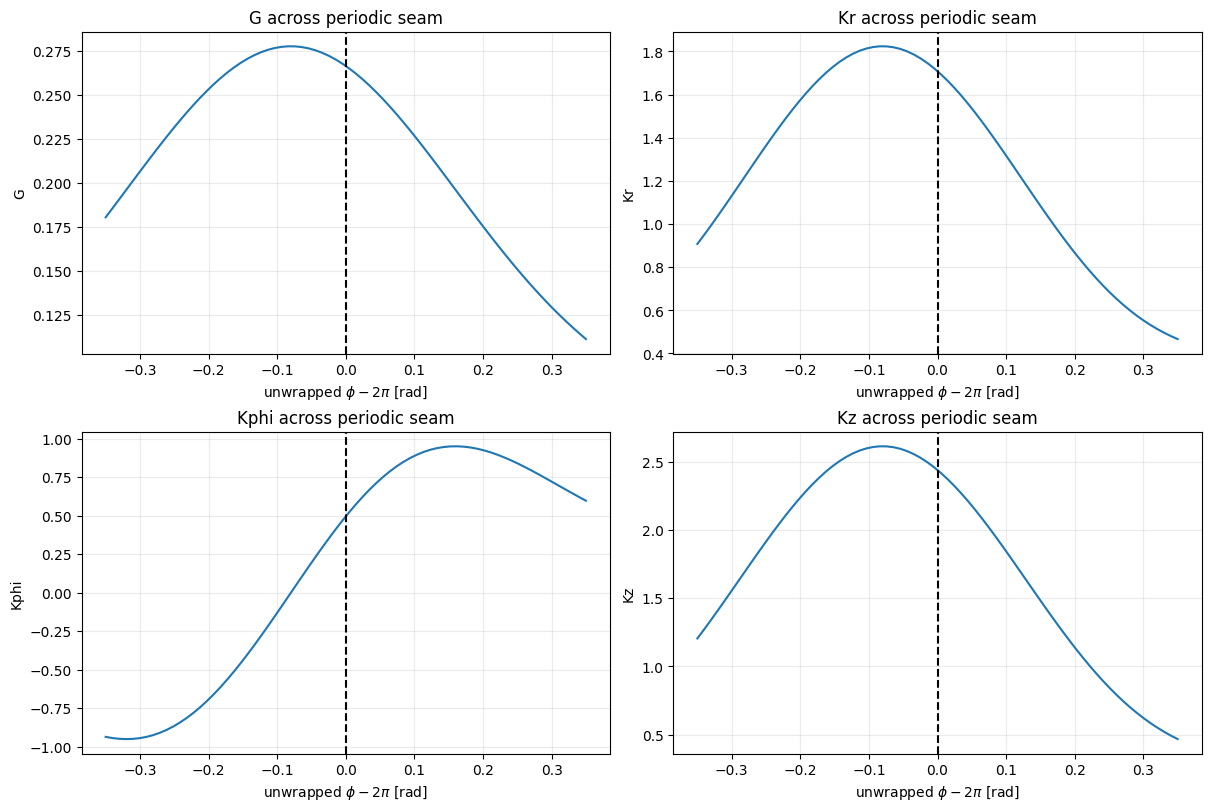

In [10]:

if DO_PERIODICITY_QA:
    phi_scan_unwrapped = np.linspace(
        2.0*np.pi-0.35,
        2.0*np.pi+0.35,
        PHI_QA_NBINS,
    )

    source_for_scan = (
        0.46,
        2.0*np.pi-0.08,
        0.45,
    )

    scan_values = np.array([
        green_point(
            0.55,
            phi_value,
            0.60,
            *source_for_scan,
        )
        for phi_value in phi_scan_unwrapped
    ])

    fig,axes = plt.subplots(
        2,
        2,
        figsize=(12,8),
        constrained_layout=True,
    )

    for ax,index,label in zip(
        axes.ravel(),
        range(4),
        ["G", "Kr", "Kphi", "Kz"],
    ):
        ax.plot(
            phi_scan_unwrapped-2.0*np.pi,
            scan_values[:,index],
        )
        ax.axvline(0.0, color="black", linestyle="--")
        ax.set_xlabel(r"unwrapped $\phi-2\pi$ [rad]")
        ax.set_ylabel(label)
        ax.set_title(f"{label} across periodic seam")
        ax.grid(alpha=0.25)

    display(fig)



### 6.3 Derivative consistency test

The field kernels are defined by derivatives of the scalar Green function:

$$
K_r=-\frac{\partial G}{\partial r},
$$

$$
K_\phi= -\frac{1}{r}
\frac{\partial G}{\partial\phi},
$$

and

$$
K_z=-\frac{\partial G}{\partial z}.
$$

We compare the analytical kernel values with finite-difference derivatives of the pointwise scalar Green function.

For the radial derivative,

$$
K_r(r,\phi,z;\mathbf{x}')
\approx-\frac{
G(r+\Delta r,\phi,z;\mathbf{x}')-G(r-\Delta r,\phi,z;\mathbf{x}')
}{
2\Delta r
}.
$$

For the azimuthal derivative,

$$
K_\phi(r,\phi,z;\mathbf{x}')
\approx-\frac{1}{r}
\frac{
G(r,\phi+\Delta\phi,z;\mathbf{x}')-G(r,\phi-\Delta\phi,z;\mathbf{x}')
}{
2\Delta\phi
}.
$$

For the longitudinal derivative,

$$
K_z(r,\phi,z;\mathbf{x}')
\approx-\frac{
G(r,\phi,z+\Delta z;\mathbf{x}')-G(r,\phi,z-\Delta z;\mathbf{x}')
}{
2\Delta z
}.
$$

The analytical and finite-difference values should agree away from boundaries and away from the source singularity.

---


In [11]:
# ============================================================
# Derivative consistency QA
# ============================================================

# Choose an observation point and source point away from
# boundaries and away from each other.
x_obs = (0.52, 0.90, 0.61)
x_src = (0.43, 2.00, 0.37)

r, p, z = x_obs
rp, pp, zp = x_src

# Analytical Green function and kernels
g0, kr_analytic, kp_analytic, kz_analytic = green_point(
    r, p, z,
    rp, pp, zp
)

# Small finite-difference steps
dr = 1.0e-5
dphi = 1.0e-5
dz = 1.0e-5

# Radial finite difference
g_r_plus = green_point(
    r + dr, p, z,
    rp, pp, zp
)[0]

g_r_minus = green_point(
    r - dr, p, z,
    rp, pp, zp
)[0]

kr_fd = -(
    g_r_plus - g_r_minus
)/(2.0*dr)

# Azimuthal finite difference
g_phi_plus = green_point(
    r, p + dphi, z,
    rp, pp, zp
)[0]

g_phi_minus = green_point(
    r, p - dphi, z,
    rp, pp, zp
)[0]

kp_fd = -(
    g_phi_plus - g_phi_minus
)/(2.0*dphi*r)

# Longitudinal finite difference
g_z_plus = green_point(
    r, p, z + dz,
    rp, pp, zp
)[0]

g_z_minus = green_point(
    r, p, z - dz,
    rp, pp, zp
)[0]

kz_fd = -(
    g_z_plus - g_z_minus
)/(2.0*dz)

def relative_difference(a, b):
    return abs(a - b)/max(abs(a), abs(b), 1.0e-30)

print("Derivative consistency test")
print()

print("Kr:")
print("  analytical =", kr_analytic)
print("  finite difference =", kr_fd)
print(
    "  relative difference =",
    relative_difference(kr_analytic, kr_fd)
)

print()

print("Kphi:")
print("  analytical =", kp_analytic)
print("  finite difference =", kp_fd)
print(
    "  relative difference =",
    relative_difference(kp_analytic, kp_fd)
)

print()

print("Kz:")
print("  analytical =", kz_analytic)
print("  finite difference =", kz_fd)
print(
    "  relative difference =",
    relative_difference(kz_analytic, kz_fd)
)

Derivative consistency test

Kr:
  analytical = 0.007892152193382851
  finite difference = 0.007892151984104784
  relative difference = 2.6517236613050658e-08

Kphi:
  analytical = -0.09002024026894523
  finite difference = -0.09002024024677754
  relative difference = 2.4625222381748885e-10

Kz:
  analytical = 0.04886524713140485
  finite difference = 0.048865247120281195
  relative difference = 2.276394411904621e-10


## 6. Visual QA of the Green function and field kernels

This cell creates two-dimensional ROOT histograms and displays \(r\)-\(z\) slices of the Green-function response for one fixed source point.

The full arrays

$$
G(r,\phi,z;r',\phi',z'),
$$

$$
K_r(r,\phi,z;r',\phi',z'),
$$

and

$$
K_z(r,\phi,z;r',\phi',z')
$$

depend on six coordinates.

To visualize them, the source coordinates are fixed to one selected source position,

$$
r' \approx 0.50\ \mathrm{m},
$$

$$
\phi' \approx 0,
$$

$$
z' \approx 0.54\ \mathrm{m}.
$$

The remaining observation coordinates are then displayed as two-dimensional maps in

$$
(r,z).
$$

Because the default calculation is axisymmetric, the response should not depend on the observation angle \(\phi\). The code therefore averages over the observation-\(\phi\) axis before plotting.

---

### 6.1 ROOT objects used for plotting

The code begins with

```python
qa_objects = []
qa_canvases = []

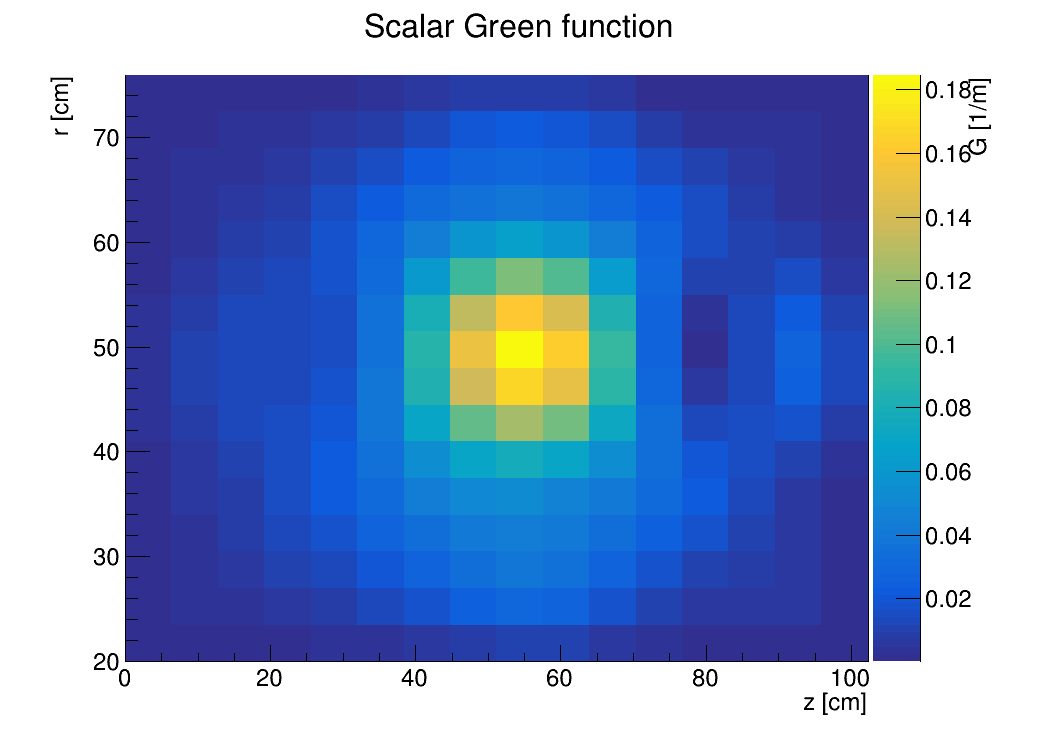

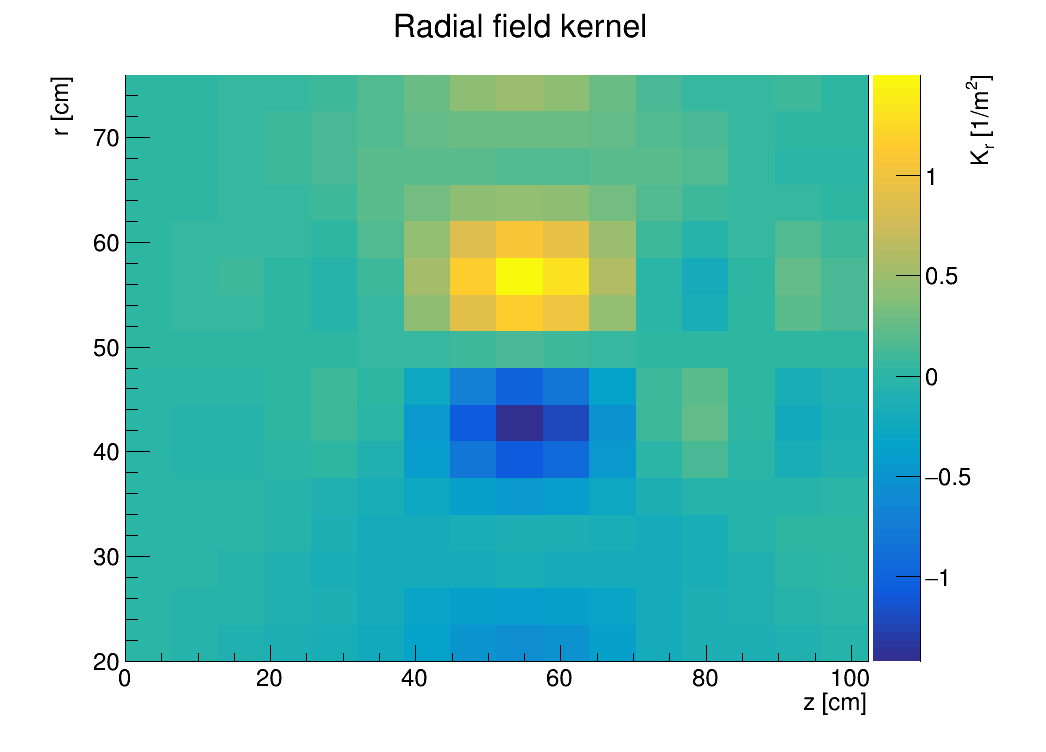

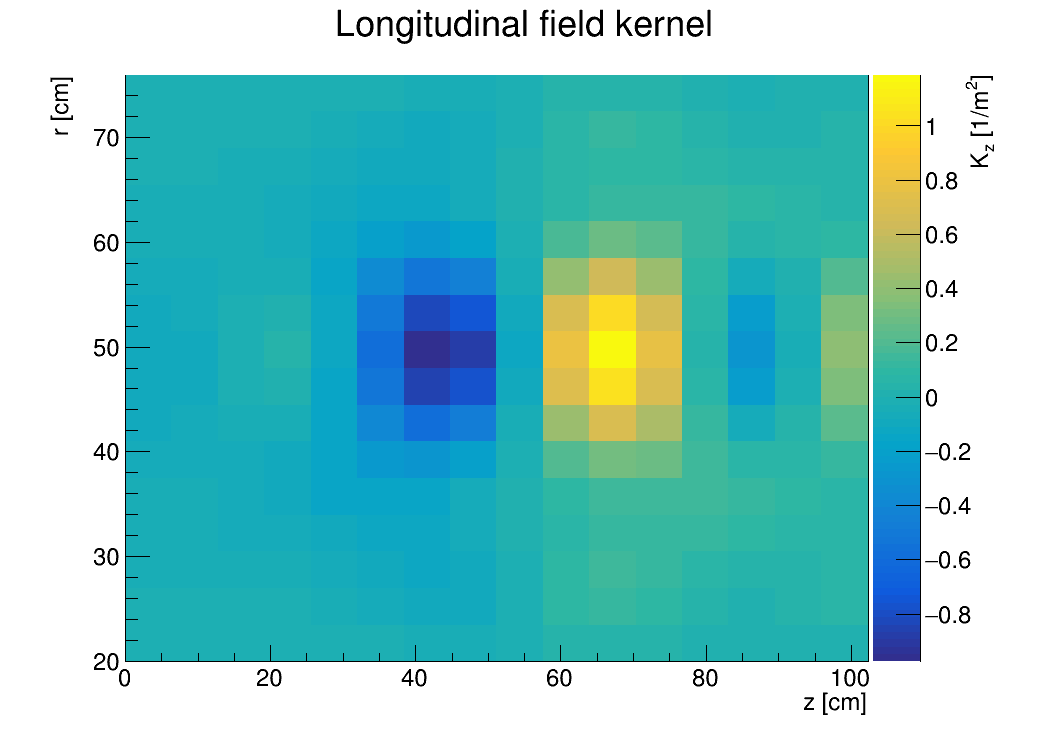

Info in <TCanvas::Print>: png file direct_green_qa/green_G.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/green_Kr.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/green_Kz.png has been created


In [12]:
qa_objects=[]; qa_canvases=[]
def make_th2(name,title,v,xe,ye,xt,yt,zt):
    h=root.TH2D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"))
    h.SetDirectory(0); h.GetXaxis().SetTitle(xt); h.GetYaxis().SetTitle(yt); h.GetZaxis().SetTitle(zt)
    for i in range(v.shape[0]):
        for j in range(v.shape[1]): h.SetBinContent(i+1,j+1,float(v[i,j]))
    qa_objects.append(h); return h
def draw(stem,h):
    c=root.TCanvas(stem,"",1050,780); c.SetRightMargin(.17); c.SetLeftMargin(.12); c.SetBottomMargin(.12)
    h.Draw("COLZ"); c.Update()
    fn=QA_DIR/f"{stem}.png"; c.SaveAs(str(fn)); display(Image(filename=str(fn)))
    qa_canvases.append(c)

if DO_QA:
    irs = np.argmin(abs(r_src - 0.50))
    ips = np.argmin(abs(phi_src))
    izs = np.argmin(abs(z_src - 0.54))

    for stem, arr, title, ztitle in [
        ("green_G",  G,  "Scalar Green function", "G [1/m]"),
        ("green_Kr", Kr, "Radial field kernel", "K_{r} [1/m^{2}]"),
        ("green_Kz", Kz, "Longitudinal field kernel", "K_{z} [1/m^{2}]")
    ]:
        # Fix the source coordinates and average over observation phi.
        # The resulting array initially has shape (NR_OBS, NZ_OBS),
        # corresponding to (r, z).
        sl = np.mean(
            arr[:, :, :, irs, ips, izs],
            axis=1
        )

        draw(
            stem,
            make_th2(
                "h" + stem,
                title,
                sl.T,
                z_obs_edges * M_TO_CM,
                r_obs_edges * M_TO_CM,
                "z [cm]",
                "r [cm]",
                ztitle
            )
        )


### 6.5 Three-plane kernel QA for the cylindrical geometry

For one fixed source point we now inspect every kernel in all three natural
cylindrical planes:

- \(r\)-\(z\) at fixed observation \(\phi\);
- \(\phi\)-\(z\) at fixed observation \(r\);
- \(\phi\)-\(r\) at fixed observation \(z\).

The \(\phi\) axes cover the complete interval \(0\leq\phi<2\pi\). To avoid
being limited by the small dense-kernel azimuthal grid, these QA maps are
evaluated with the pointwise Green-function sum. This keeps the physics and
mode truncation identical to the convolution.


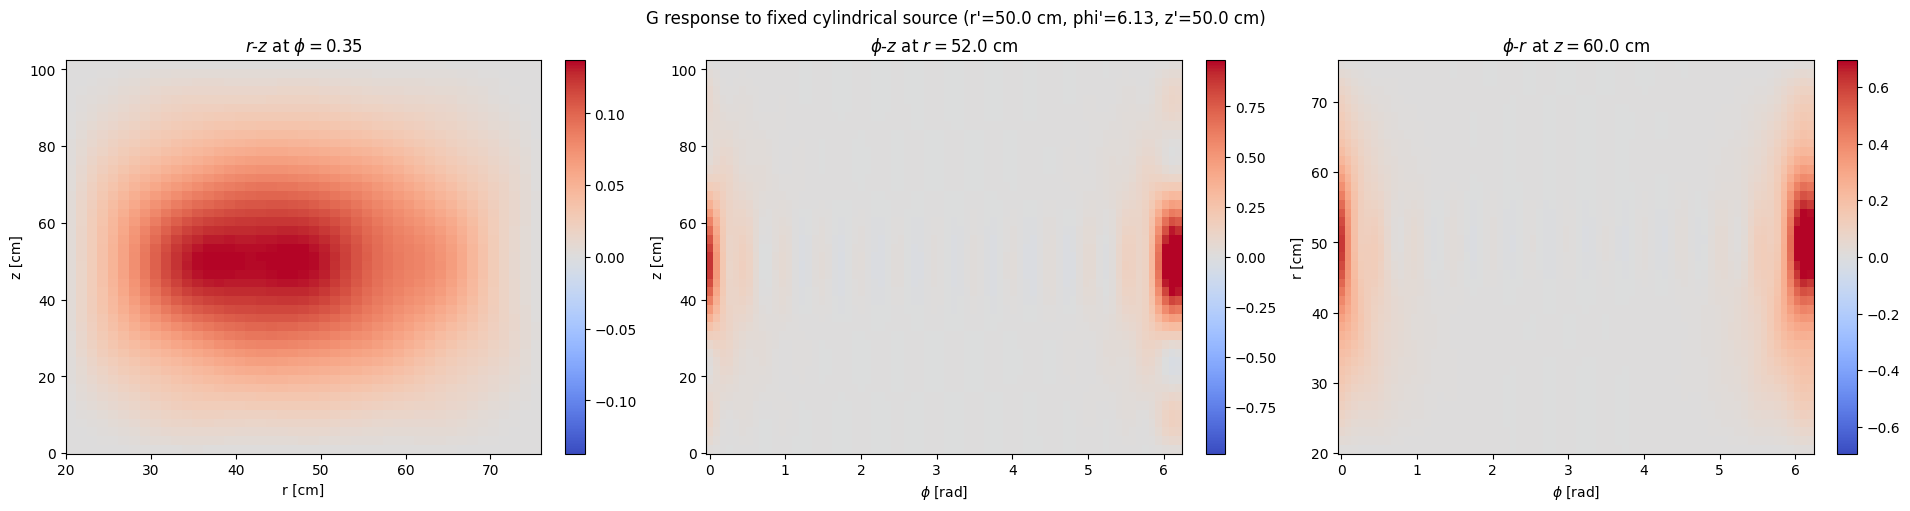

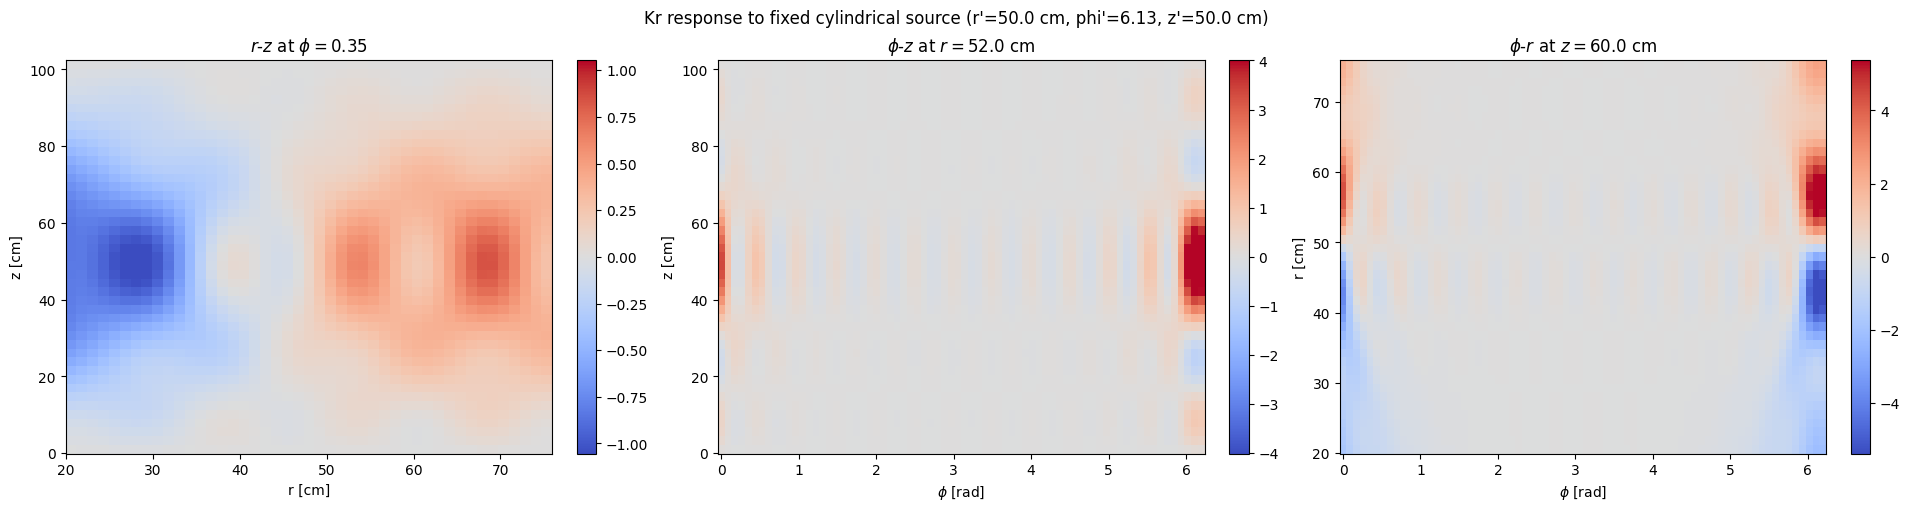

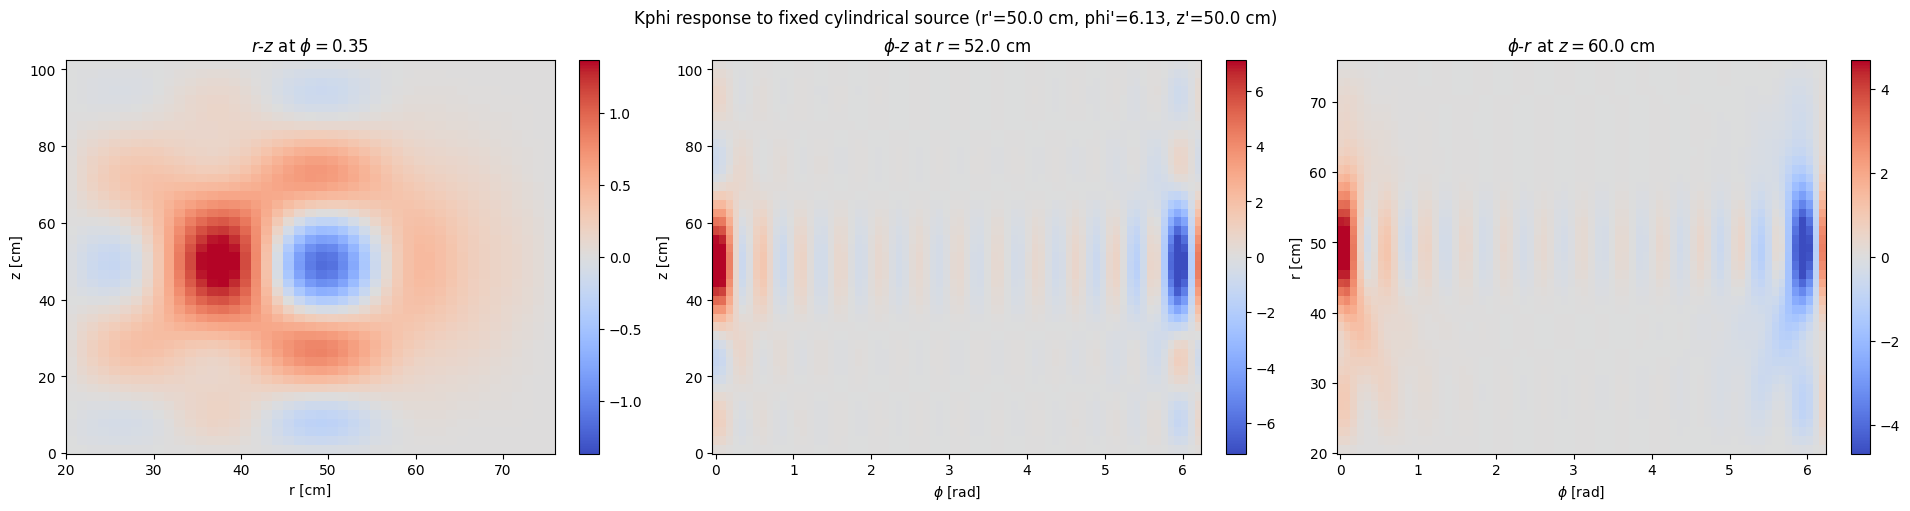

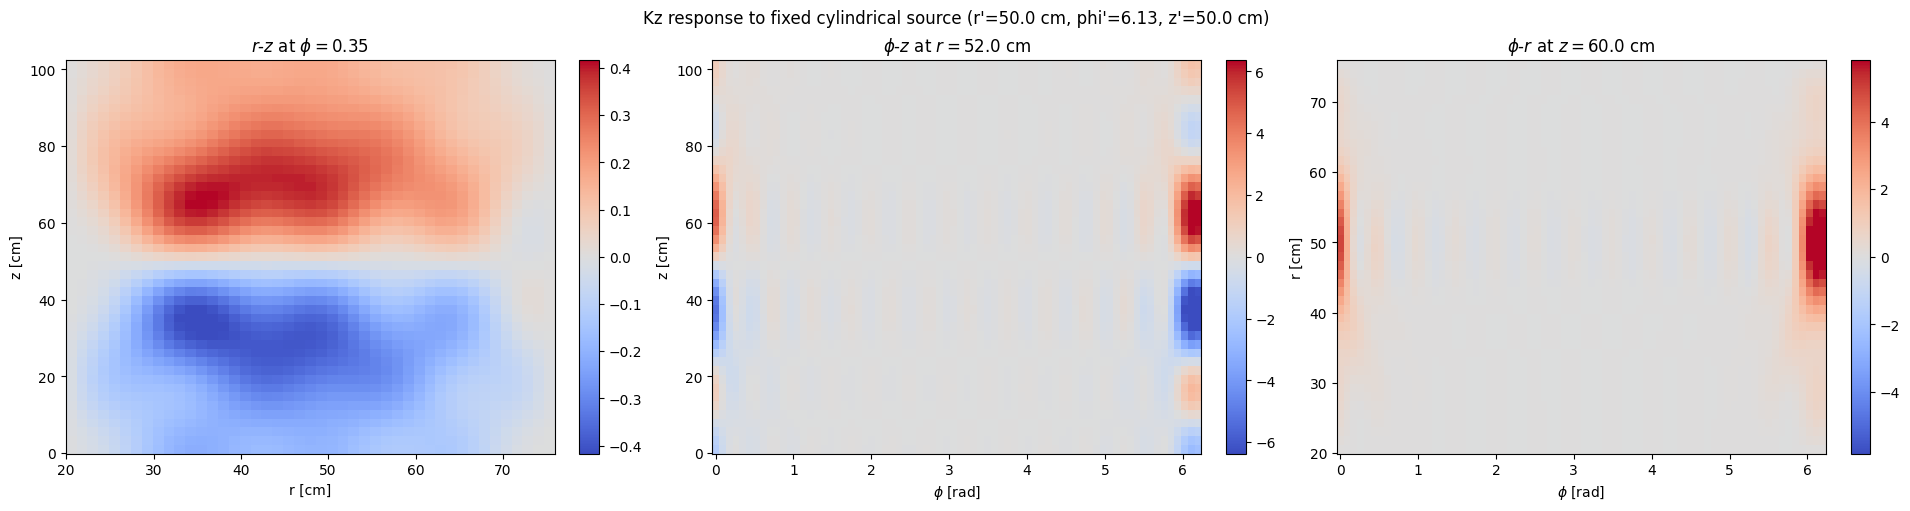

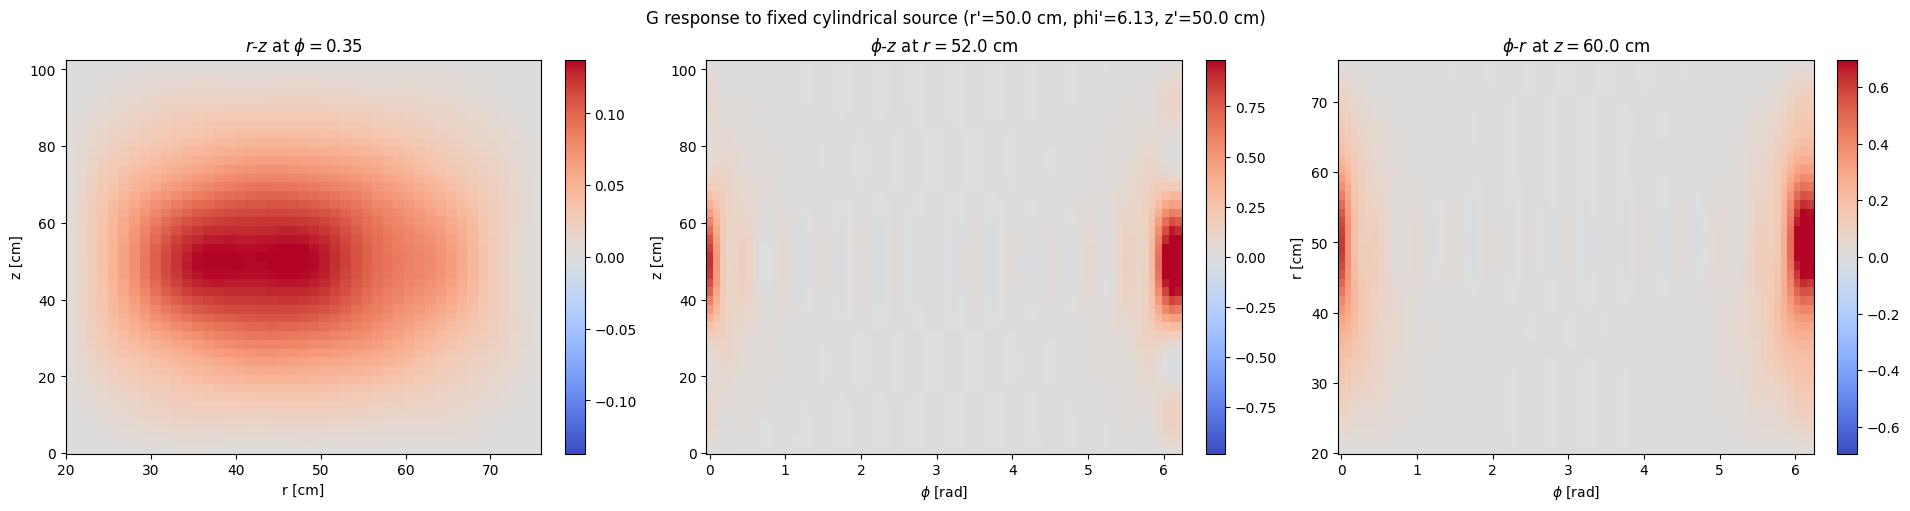

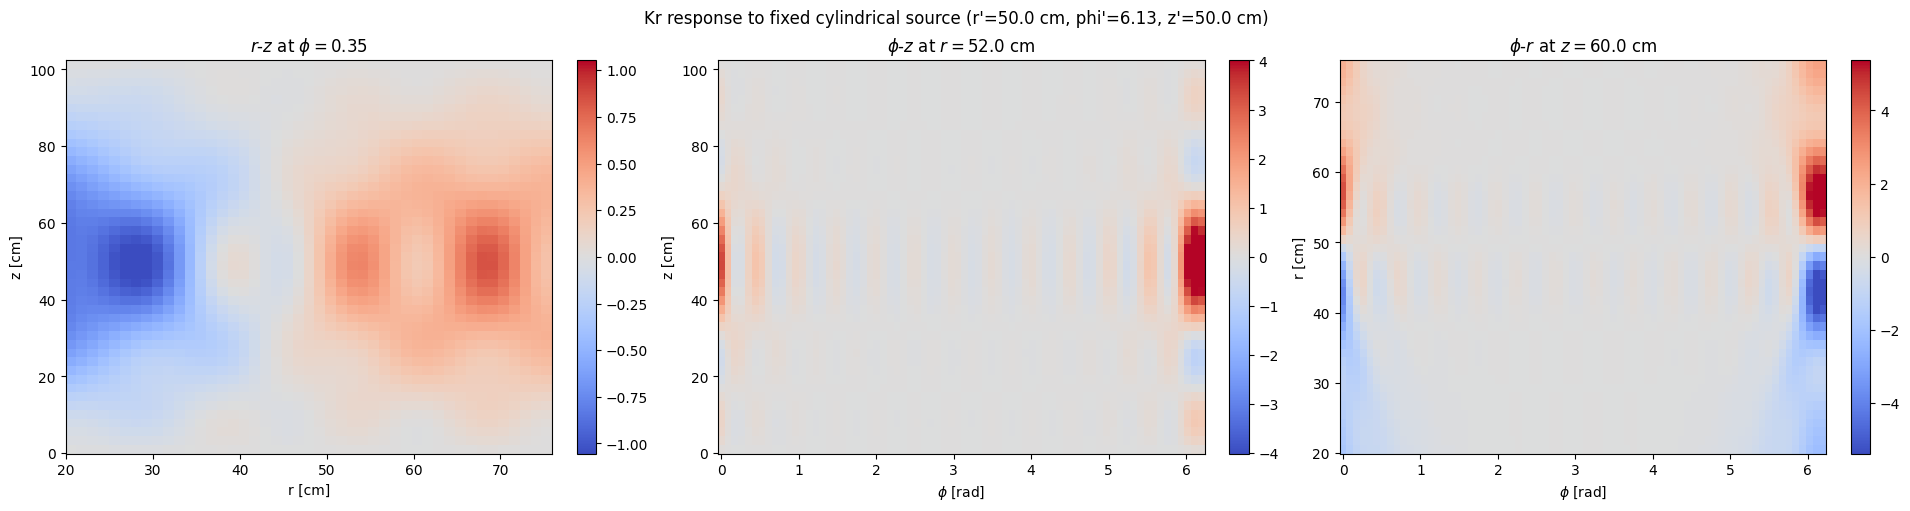

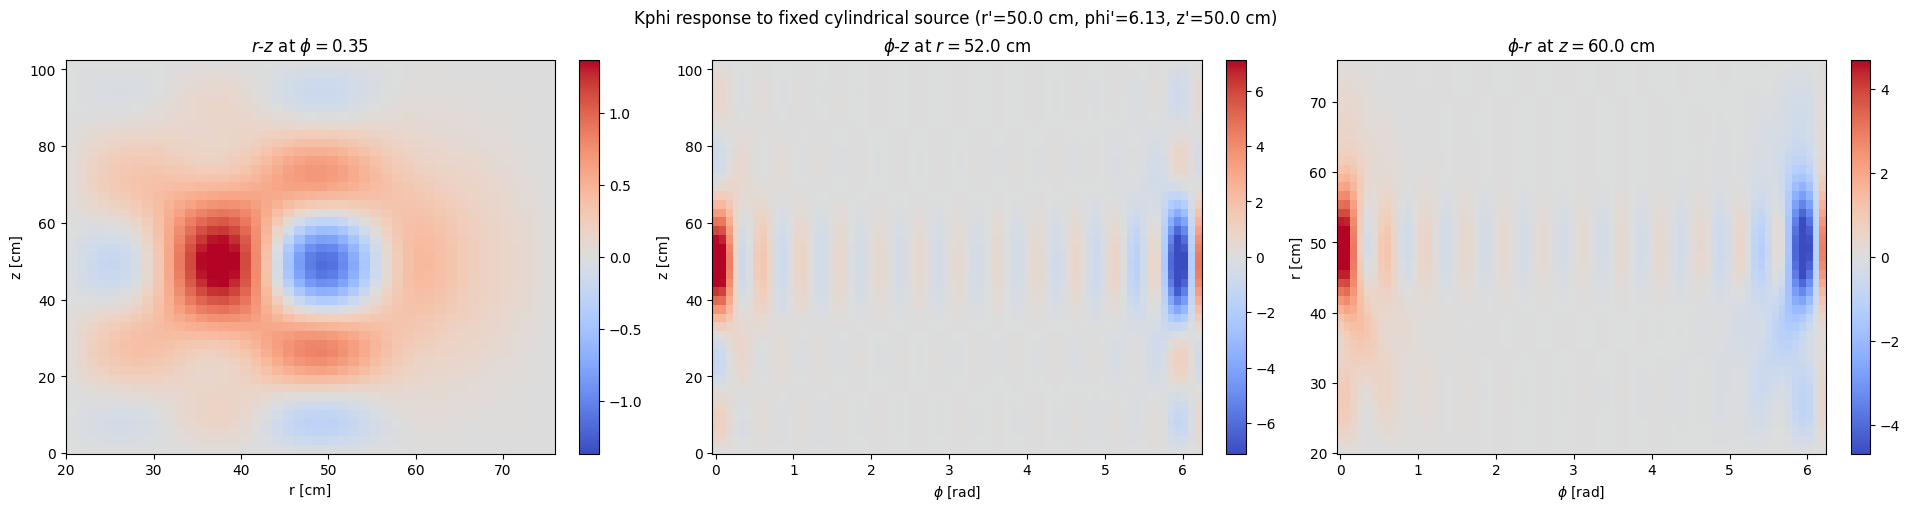

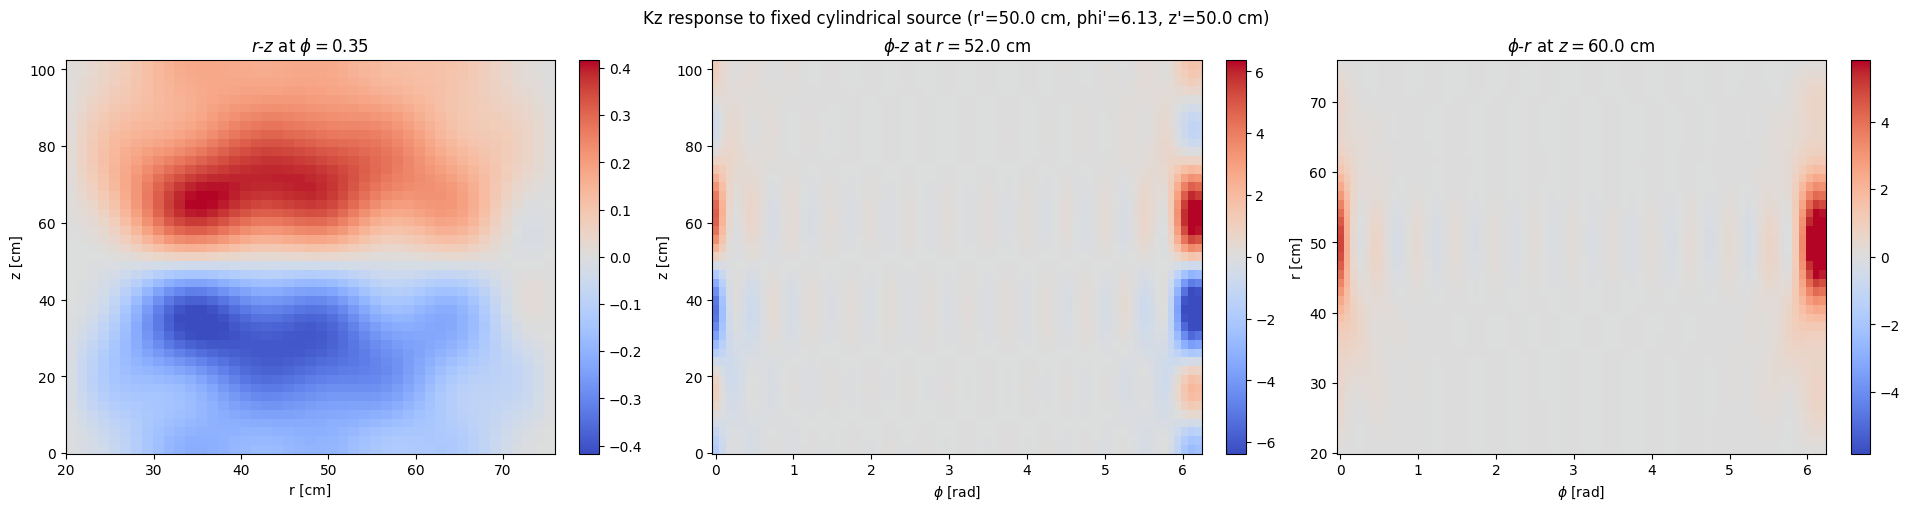

In [13]:

if DO_QA and DO_PHI_QA:
    source_r_qa = 0.50
    source_phi_qa = 2.0*np.pi-0.15
    source_z_qa = 0.50

    # Moderate plotting grids; these do not affect the convolution.
    qa_r = np.linspace(a+0.01*(b-a), b-0.01*(b-a), 45)
    qa_phi = np.linspace(0.0, 2.0*np.pi, PHI_QA_NBINS, endpoint=False)
    qa_z = np.linspace(0.01*L, 0.99*L, 45)

    qa_r_edges = np.linspace(a, b, len(qa_r)+1)
    qa_phi_edges = np.linspace(0.0, 2.0*np.pi, len(qa_phi)+1)
    qa_z_edges = np.linspace(0.0, L, len(qa_z)+1)

    phi_fixed = 0.35
    r_fixed = 0.52
    z_fixed = 0.60

    # r-z maps
    kernel_rz = {
        name: np.empty((len(qa_z), len(qa_r)))
        for name in ["G", "Kr", "Kphi", "Kz"]
    }

    for iz,zv in enumerate(qa_z):
        for ir,rv in enumerate(qa_r):
            values = green_point(
                rv, phi_fixed, zv,
                source_r_qa, source_phi_qa, source_z_qa,
            )
            for name,value in zip(kernel_rz, values):
                kernel_rz[name][iz,ir] = value

    # phi-z maps
    kernel_phiz = {
        name: np.empty((len(qa_z), len(qa_phi)))
        for name in ["G", "Kr", "Kphi", "Kz"]
    }

    for iz,zv in enumerate(qa_z):
        for ip,pv in enumerate(qa_phi):
            values = green_point(
                r_fixed, pv, zv,
                source_r_qa, source_phi_qa, source_z_qa,
            )
            for name,value in zip(kernel_phiz, values):
                kernel_phiz[name][iz,ip] = value

    # phi-r maps
    kernel_phir = {
        name: np.empty((len(qa_r), len(qa_phi)))
        for name in ["G", "Kr", "Kphi", "Kz"]
    }

    for ir,rv in enumerate(qa_r):
        for ip,pv in enumerate(qa_phi):
            values = green_point(
                rv, pv, z_fixed,
                source_r_qa, source_phi_qa, source_z_qa,
            )
            for name,value in zip(kernel_phir, values):
                kernel_phir[name][ir,ip] = value

    for name in ["G", "Kr", "Kphi", "Kz"]:
        fig,axes = plt.subplots(
            1,
            3,
            figsize=(19,5),
            constrained_layout=True,
        )

        datasets = [
            (
                qa_r*M_TO_CM,
                qa_z*M_TO_CM,
                kernel_rz[name],
                "r [cm]",
                "z [cm]",
                rf"$r$-$z$ at $\phi={phi_fixed:.2f}$",
            ),
            (
                qa_phi,
                qa_z*M_TO_CM,
                kernel_phiz[name],
                r"$\phi$ [rad]",
                "z [cm]",
                rf"$\phi$-$z$ at $r={r_fixed*M_TO_CM:.1f}$ cm",
            ),
            (
                qa_phi,
                qa_r*M_TO_CM,
                kernel_phir[name],
                r"$\phi$ [rad]",
                "r [cm]",
                rf"$\phi$-$r$ at $z={z_fixed*M_TO_CM:.1f}$ cm",
            ),
        ]

        for ax,(x,y,v,xlabel,ylabel,title) in zip(axes,datasets):
            limit = np.percentile(np.abs(v), 99.5)
            if limit == 0:
                limit = 1.0

            mesh = ax.pcolormesh(
                x,
                y,
                v,
                shading="nearest",
                cmap="coolwarm",
                vmin=-limit,
                vmax=limit,
            )
            fig.colorbar(mesh, ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(title)

        fig.suptitle(
            f"{name} response to fixed cylindrical source "
            f"(r'={source_r_qa*M_TO_CM:.1f} cm, "
            f"phi'={source_phi_qa:.2f}, "
            f"z'={source_z_qa*M_TO_CM:.1f} cm)"
        )

        display(fig)


## 7. Build the charge density

Only after the Green-function QA do we define the source.

The baseline profile is

$$
\rho(r',\phi',z')
\propto
\frac{1}{r'^\alpha}
\left[
1
+
A_1\cos(\phi'-\phi_1)
+
A_{12}\cos 12(\phi'-\phi_{12})
\right].
$$

The default amplitudes are zero, so the source is axisymmetric.

The density is normalized to the requested volume-weighted mean.

In [14]:

# ----------------------------------------------------------------------
# Real sPHENIX GEM module geometry and measured module gain map
# ----------------------------------------------------------------------

import re


def require_local_file(path):
    path = Path(path)

    candidates = [
        path,
        Path.cwd() / path,
        Path("/mnt/data") / path.name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        f"Could not find {path}. Tried: "
        + ", ".join(str(candidate) for candidate in candidates)
    )


def wrapped_positive_delta(phi_to, phi_from):
    """
    Positive angular displacement from phi_from to phi_to in [0, 2*pi).
    """
    return np.mod(phi_to - phi_from, 2.0*np.pi)


def parse_pad_placement(filename):
    """
    Return exact active phi intervals indexed by:
        geometry[(region, side, sector)]

    Each interval stores:
        direction = +1 or -1
        start_edge
        angular_width
        pad_pitch

    The first and last pad centers are expanded by half one pad pitch.
    """
    filename = require_local_file(filename)

    geometry = {}
    region_info = {}
    current_region = None

    region_pattern = re.compile(
        r"region\s+(\d+)\s+"
        r"first_layer\s+(\d+)\s+"
        r"pads_per_sector\s+(\d+)\s+"
        r"total_phibins\s+(\d+)"
    )

    entry_pattern = re.compile(
        r"side\s+([01])\s+sector\s+(\d+)\s+"
        r"first_pad\s+(\d+)\s+"
        r"first_phi\s+([-+0-9.eE]+)\s+"
        r"last_pad\s+(\d+)\s+"
        r"last_phi\s+([-+0-9.eE]+)"
    )

    for raw_line in filename.read_text().splitlines():
        line = raw_line.strip()

        region_match = region_pattern.search(line)
        if region_match:
            current_region = int(region_match.group(1))
            region_info[current_region] = {
                "first_layer": int(region_match.group(2)),
                "pads_per_sector": int(region_match.group(3)),
                "total_phibins": int(region_match.group(4)),
            }
            continue

        entry_match = entry_pattern.search(line)

        if entry_match and current_region is not None:
            side = int(entry_match.group(1))
            sector = int(entry_match.group(2))
            first_pad = int(entry_match.group(3))
            first_phi = float(entry_match.group(4))
            last_pad = int(entry_match.group(5))
            last_phi = float(entry_match.group(6))

            n_steps = last_pad - first_pad
            if n_steps <= 0:
                raise RuntimeError(
                    f"Invalid pad indices for region={current_region}, "
                    f"side={side}, sector={sector}"
                )

            center_delta = float(
                wrapped_delta_phi(last_phi, first_phi)
            )
            pad_pitch = center_delta / n_steps

            # The centers run from first_phi to last_phi with signed pitch.
            # Expand both ends by one half pitch.
            start_edge = wrap_phi(first_phi - 0.5*pad_pitch)
            end_edge = wrap_phi(last_phi + 0.5*pad_pitch)

            direction = 1 if pad_pitch > 0.0 else -1

            if direction > 0:
                angular_width = wrapped_positive_delta(
                    end_edge,
                    start_edge,
                )
            else:
                angular_width = wrapped_positive_delta(
                    start_edge,
                    end_edge,
                )

            geometry[(current_region, side, sector)] = {
                "first_phi": wrap_phi(first_phi),
                "last_phi": wrap_phi(last_phi),
                "start_edge": float(start_edge),
                "end_edge": float(end_edge),
                "direction": direction,
                "angular_width": float(angular_width),
                "pad_pitch": float(pad_pitch),
            }

    expected = 3 * 2 * 12

    if len(geometry) != expected:
        raise RuntimeError(
            f"Expected {expected} geometry entries, found {len(geometry)}"
        )

    return filename, geometry, region_info


def phi_inside_interval(phi, interval):
    """
    Periodic interval test on the physical cylinder.

    This works for sectors that cross the 0/2*pi seam and sectors whose pad
    numbering runs toward either increasing or decreasing phi.
    """
    phi = wrap_phi(phi)
    start = interval["start_edge"]
    width = interval["angular_width"]

    if interval["direction"] > 0:
        traveled = wrapped_positive_delta(phi, start)
    else:
        traveled = wrapped_positive_delta(start, phi)

    return traveled <= width + 1.0e-13


def parse_gain_map(filename, method):
    """
    Read the full numeric table at the bottom of the gain file.

    Output shape:
        gain[side, sector, module]

    module index is 0,1,2 for M1,M2,M3.
    """
    filename = require_local_file(filename)

    if method not in (1, 2):
        raise ValueError("GAIN_METHOD must be 1 or 2")

    gain = np.full((2, 12, 3), np.nan, dtype=float)

    for raw_line in filename.read_text().splitlines():
        tokens = raw_line.split()

        # Full-table format:
        # side sec mod nHist nFit R_m1 ok1 R_m2 ok2 expZxNorm Gain_m1 Gain_m2
        if len(tokens) != 12:
            continue

        try:
            side = int(tokens[0])
            sector = int(tokens[1])
            module_one_based = int(tokens[2])
            gain_m1 = float(tokens[10])
            gain_m2 = float(tokens[11])
        except ValueError:
            continue

        if (
            side in (0, 1)
            and 0 <= sector < 12
            and 1 <= module_one_based <= 3
        ):
            gain[
                side,
                sector,
                module_one_based - 1,
            ] = gain_m1 if method == 1 else gain_m2

    if not np.all(np.isfinite(gain)):
        missing = np.argwhere(~np.isfinite(gain))
        raise RuntimeError(
            f"Gain map is incomplete. Missing indices: {missing.tolist()}"
        )

    return filename, gain


pad_file_used, pad_geometry, pad_region_info = parse_pad_placement(
    PAD_PLACEMENT_FILE
)

gain_file_used, gain_map = parse_gain_map(
    GAIN_MAP_FILE,
    GAIN_METHOD,
)

# Exact radial GEM active ranges in cm.
#
# R1 includes the antenna-pad area. Its area is treated as active GEM area,
# as requested.
MODULE_R_BOUNDS_CM = np.array(
    [
        [22.8132065669, 40.0513196955],
        [41.59330537774673, 57.03543628903930],
        [58.84508531801007, 75.43255308254751],
    ],
    dtype=float,
)

MODULE_R_BOUNDS_M = MODULE_R_BOUNDS_CM * CM_TO_M

print("Pad geometry:", pad_file_used)
print("Gain map:", gain_file_used)
print("TPC side:", TPC_SIDE)
print("Gain method:", GAIN_METHOD)
print("Module radial bounds [cm]:")
for module in range(3):
    print(
        f"  M{module+1}: "
        f"{MODULE_R_BOUNDS_CM[module,0]:.9f} to "
        f"{MODULE_R_BOUNDS_CM[module,1]:.9f}"
    )

# ----------------------------------------------------------------------
# Build the real module/sector mask on source cell centers.
# ----------------------------------------------------------------------

R3 = r_src[:, None, None]
P3 = phi_src[None, :, None]

module_index_rphi = np.full(
    (NR_SRC, NPHI_SRC),
    -1,
    dtype=np.int32,
)

sector_index_rphi = np.full(
    (NR_SRC, NPHI_SRC),
    -1,
    dtype=np.int32,
)

geometry_mask_rphi = np.zeros(
    (NR_SRC, NPHI_SRC),
    dtype=float,
)

gain_factor_rphi = np.zeros(
    (NR_SRC, NPHI_SRC),
    dtype=float,
)

for module in range(3):
    r_low, r_high = MODULE_R_BOUNDS_M[module]

    radial_selection = (
        (r_src >= r_low)
        & (r_src <= r_high)
    )

    for sector in range(12):
        interval = pad_geometry[
            (module, TPC_SIDE, sector)
        ]

        phi_selection = phi_inside_interval(
            phi_src,
            interval,
        )

        selection = (
            radial_selection[:, None]
            & phi_selection[None, :]
        )

        if np.any(
            (module_index_rphi >= 0)
            & selection
        ):
            raise RuntimeError(
                f"Overlapping GEM geometry for module={module}, "
                f"sector={sector}"
            )

        module_index_rphi[selection] = module
        sector_index_rphi[selection] = sector
        geometry_mask_rphi[selection] = 1.0

        if MULTIPLY_CHARGE_BY_GAIN:
            gain_factor_rphi[selection] = gain_map[
                TPC_SIDE,
                sector,
                module,
            ]
        else:
            gain_factor_rphi[selection] = 1.0

active_cells_rphi = geometry_mask_rphi > 0.0

if not np.any(active_cells_rphi):
    raise RuntimeError(
        "No source-grid cells fall inside the real GEM geometry. "
        "Increase NPHI_SRC and check radial source limits."
    )

# Radial source model. This retains the existing notebook parameter.
radial_shape = (
    rs0 / R3
) ** RADIAL_POWER_ALPHA

base_raw = (
    radial_shape
    * geometry_mask_rphi[:, :, None]
    * np.ones((1, 1, NZ_SRC))
)

gain_raw = (
    base_raw
    * gain_factor_rphi[:, :, None]
)

# Normalize only the gain-induced imbalance, preserving the total charge
# that the same real GEM geometry would have with unit gain.
if (
    MULTIPLY_CHARGE_BY_GAIN
    and NORMALIZE_GAIN_WEIGHTED_TOTAL
):
    base_integral = np.sum(
        base_raw * dV
    )

    gain_integral = np.sum(
        gain_raw * dV
    )

    if base_integral <= 0.0 or gain_integral <= 0.0:
        raise RuntimeError(
            "Invalid base/gain charge normalization integrals"
        )

    gain_normalization = (
        gain_integral
        / base_integral
    )

    raw = gain_raw / gain_normalization
else:
    gain_normalization = 1.0
    raw = gain_raw

if np.min(raw) < 0.0:
    raise ValueError("Negative charge density shape")

# Preserve the original notebook's global mean charge-density convention.
target = (
    K_EFF
    * RHO_REFERENCE_NC_PER_M3
    * 1.0e-9
)

raw_volume_average = (
    np.sum(raw * dV)
    / np.sum(dV)
)

if raw_volume_average <= 0.0:
    raise RuntimeError(
        "Charge-density shape has zero volume average"
    )

rho = (
    target
    * raw
    / raw_volume_average
)

charge = rho * dV

print()
print("Real GEM source summary")
print("  Active r-phi cells:", int(np.count_nonzero(active_cells_rphi)))
print("  Total r-phi cells:", int(active_cells_rphi.size))
print(
    "  Active fraction:",
    np.count_nonzero(active_cells_rphi)
    / active_cells_rphi.size,
)
print("  Raw gain normalization:", gain_normalization)
print(
    "  Gain values on active cells:",
    np.min(gain_factor_rphi[active_cells_rphi]),
    "to",
    np.max(gain_factor_rphi[active_cells_rphi]),
)
print("  Q total =", np.sum(charge), "C")
print(
    "  Mean rho over full source cylinder =",
    np.sum(rho*dV)/np.sum(dV),
    "C/m^3",
)

# ----------------------------------------------------------------------
# PyROOT QA: module map, gain map, and z-averaged rho in phi-r.
# No Matplotlib is used.
# ----------------------------------------------------------------------

def make_root_th2(
    name,
    title,
    values_rphi,
):
    hist = root.TH2F(
        name,
        title,
        len(phi_src_edges)-1,
        np.asarray(phi_src_edges, dtype="d"),
        len(r_src_edges)-1,
        np.asarray(r_src_edges*M_TO_CM, dtype="d"),
    )

    hist.SetDirectory(0)

    for ir in range(values_rphi.shape[0]):
        for iphi in range(values_rphi.shape[1]):
            hist.SetBinContent(
                iphi + 1,
                ir + 1,
                float(values_rphi[ir, iphi]),
            )

    return hist


module_display = np.where(
    module_index_rphi >= 0,
    module_index_rphi + 1,
    0,
)

gain_display = np.where(
    active_cells_rphi,
    gain_factor_rphi,
    0.0,
)

rho_mean_z = np.mean(
    rho,
    axis=2,
) * 1.0e9

h_module_geometry = make_root_th2(
    "hRealGemModuleGeometry",
    "Real GEM module geometry;#phi [rad];r [cm];module",
    module_display,
)

h_gain_geometry = make_root_th2(
    "hRealGemGain",
    (
        f"Real GEM gain, side {TPC_SIDE}, method {GAIN_METHOD};"
        "#phi [rad];r [cm];gain"
    ),
    gain_display,
)

h_rho_geometry = make_root_th2(
    "hRealGemRho",
    (
        "Ion charge density with real GEM geometry;"
        "#phi [rad];r [cm];<#rho>_{z} [nC/m^{3}]"
    ),
    rho_mean_z,
)

c_real_gem_source = root.TCanvas(
    "cRealGemSource",
    "Real GEM source geometry and gains",
    1800,
    600,
)

c_real_gem_source.Divide(3, 1)

c_real_gem_source.cd(1)
root.gPad.SetRightMargin(0.15)
h_module_geometry.SetMinimum(0.0)
h_module_geometry.SetMaximum(3.0)
h_module_geometry.Draw("COLZ")

c_real_gem_source.cd(2)
root.gPad.SetRightMargin(0.15)
h_gain_geometry.Draw("COLZ")

c_real_gem_source.cd(3)
root.gPad.SetRightMargin(0.15)
h_rho_geometry.Draw("COLZ")

c_real_gem_source.Update()
display(c_real_gem_source)


FileNotFoundError: Could not find TPC_pad_placement.txt. Tried: TPC_pad_placement.txt, /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/distort/gpt/TPC_pad_placement.txt, /mnt/data/TPC_pad_placement.txt


### 7.1 Cylindrical source QA

The source is checked directly in all cylindrical projections. The
volume-weighted \(\phi\) profile must close continuously between the final and
first bins. For an axisymmetric source, the profile must be flat to numerical
precision and \(E_\phi\) must vanish after convolution.


In [ ]:

if DO_QA:
    rho_rz = np.mean(rho, axis=1)
    rho_phiz = np.mean(rho, axis=0)
    rho_phir = np.mean(rho, axis=2).T

    fig,axes = plt.subplots(
        1,
        3,
        figsize=(19,5),
        constrained_layout=True,
    )

    source_maps = [
        (
            z_src*M_TO_CM,
            r_src*M_TO_CM,
            rho_rz*1e9,
            "z [cm]",
            "r [cm]",
            r"$r$-$z$, averaged over $\phi$",
        ),
        (
            phi_src,
            z_src*M_TO_CM,
            rho_phiz.T*1e9,
            r"$\phi$ [rad]",
            "z [cm]",
            r"$\phi$-$z$, averaged over $r$",
        ),
        (
            phi_src,
            r_src*M_TO_CM,
            rho_phir*1e9,
            r"$\phi$ [rad]",
            "r [cm]",
            r"$\phi$-$r$, averaged over $z$",
        ),
    ]

    for ax,(x,y,v,xlabel,ylabel,title) in zip(axes,source_maps):
        mesh = ax.pcolormesh(
            x,
            y,
            v,
            shading="nearest",
        )
        fig.colorbar(
            mesh,
            ax=ax,
            label=r"$\rho$ [nC/m$^3$]",
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    fig.suptitle("Cylindrical source-density QA")
    display(fig)

    # Volume-weighted charge in each phi bin.
    charge_vs_phi = np.sum(charge, axis=(0,2))

    mean_charge_phi = np.mean(charge_vs_phi)
    relative_phi_rms = (
        np.std(charge_vs_phi)
        / max(abs(mean_charge_phi), 1.0e-30)
    )

    closure_difference = (
        charge_vs_phi[0] - charge_vs_phi[-1]
    )

    print("Charge-vs-phi relative RMS:", relative_phi_rms)
    print(
        "First-last phi-bin charge difference [C]:",
        closure_difference,
    )

    if phi_uniform:
        assert relative_phi_rms < 1.0e-12


## 8. Direct convolution

The discrete form of the Green-function integral is

$$
\Phi_i
=
\frac{1}{\epsilon_0}
\sum_j G_{ij}\Delta Q_j,
$$

with

$$
\Delta Q_j=\rho_j\Delta V_j.
$$

Likewise,

$$
E_{r,i}
=
\frac{1}{\epsilon_0}
\sum_j K_{r,ij}\Delta Q_j,
$$

and similarly for $E_\phi$ and $E_z$.

The six-dimensional arrays are reshaped into matrices of size

$$
N_{\rm obs}\times N_{\rm src},
$$

and multiplied by the source-charge vector.

### Meaning of the indices \(i\) and \(j\)

In the discrete equations,

$$
\Phi_i
=
\frac{1}{\epsilon_0}
\sum_j
G_{ij}\Delta Q_j,
$$

the index \(i\) labels one observation-grid point,

$$
i
\longleftrightarrow
(r_i,\phi_i,z_i),
$$

while the index \(j\) labels one source-grid voxel,

$$
j
\longleftrightarrow
(r'_j,\phi'_j,z'_j).
$$

So each row of the reshaped Green matrix corresponds to one observation bin in

$$
(r,\phi,z),
$$

and each column corresponds to one source bin in

$$
(r',\phi',z').
$$

The original Green-function array has shape

```python
(
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
    NR_SRC,
    NPHI_SRC,
    NZ_SRC
)

In [ ]:
qvec=charge.reshape(NSRC)
Phi=(G.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Er=(Kr.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ephi=(Kp.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)
Ez=(Kz.reshape(NOBS,NSRC)@qvec/EPSILON_0).reshape(NR_OBS,NPHI_OBS,NZ_OBS)

print("max |Phi|",np.max(abs(Phi)))
print("max |Er|",np.max(abs(Er)))
print("max |Ephi|",np.max(abs(Ephi)))
print("max |Ez|",np.max(abs(Ez)))

max |Phi| 88.78502472265413
max |Er| 1159.6573963293756
max |Ephi| 0.0
max |Ez| 539.108154406405



### 8.1 Three-plane field QA and periodic closure

The convolved potential and cylindrical field components are displayed in the
same three planes used for the Green-function QA:

- \(r\)-\(z\), averaged over \(\phi\);
- \(\phi\)-\(z\), averaged over \(r\);
- \(\phi\)-\(r\), averaged over \(z\).

The first and last sampled \(\phi\) bins are adjacent cells on the cylinder.
Their difference is compared with all other adjacent-bin differences. A
periodic seam problem would make the closure step anomalously large.


In [ ]:

if DO_QA:
    fields_for_qa = {
        "Phi": Phi,
        "Er": Er,
        "Ephi": Ephi,
        "Ez": Ez,
    }

    for name,array3d in fields_for_qa.items():
        rz = np.mean(array3d, axis=1)
        phiz = np.mean(array3d, axis=0)
        phir = np.mean(array3d, axis=2).T

        fig,axes = plt.subplots(
            1,
            3,
            figsize=(19,5),
            constrained_layout=True,
        )

        maps = [
            (
                z_obs*M_TO_CM,
                r_obs*M_TO_CM,
                rz,
                "z [cm]",
                "r [cm]",
                r"$r$-$z$, averaged over $\phi$",
            ),
            (
                phi_obs,
                z_obs*M_TO_CM,
                phiz.T,
                r"$\phi$ [rad]",
                "z [cm]",
                r"$\phi$-$z$, averaged over $r$",
            ),
            (
                phi_obs,
                r_obs*M_TO_CM,
                phir,
                r"$\phi$ [rad]",
                "r [cm]",
                r"$\phi$-$r$, averaged over $z$",
            ),
        ]

        for ax,(x,y,v,xlabel,ylabel,title) in zip(axes,maps):
            if name == "Phi":
                mesh = ax.pcolormesh(
                    x,
                    y,
                    v,
                    shading="nearest",
                )
            else:
                limit = np.percentile(np.abs(v), 99.5)
                if limit == 0:
                    limit = 1.0

                mesh = ax.pcolormesh(
                    x,
                    y,
                    v,
                    shading="nearest",
                    cmap="coolwarm",
                    vmin=-limit,
                    vmax=limit,
                )

            fig.colorbar(mesh, ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.set_title(title)

        fig.suptitle(f"Cylindrical QA: {name}")
        display(fig)

    def periodic_adjacent_step_summary(array3d):
        # Difference between every phi bin and its next neighbor,
        # including last -> first through np.roll.
        adjacent = (
            np.roll(array3d, -1, axis=1)
            - array3d
        )

        step_rms_by_phi = np.sqrt(
            np.mean(adjacent**2, axis=(0,2))
        )

        closure_step = step_rms_by_phi[-1]
        ordinary_steps = step_rms_by_phi[:-1]
        median_step = np.median(ordinary_steps)

        return (
            closure_step,
            median_step,
            closure_step/max(median_step, 1.0e-30),
        )

    print("Periodic closure diagnostics")
    for name,array3d in fields_for_qa.items():
        closure,median,ratio = periodic_adjacent_step_summary(array3d)
        print(
            f"  {name:5s}: "
            f"closure RMS={closure:.6e}, "
            f"median adjacent RMS={median:.6e}, "
            f"ratio={ratio:.6f}"
        )

    if phi_uniform:
        phi_rms_er = np.sqrt(
            np.mean(
                (
                    Er-np.mean(Er,axis=1,keepdims=True)
                )**2
            )
        )

        phi_rms_ephi = np.sqrt(np.mean(Ephi**2))

        phi_rms_ez = np.sqrt(
            np.mean(
                (
                    Ez-np.mean(Ez,axis=1,keepdims=True)
                )**2
            )
        )

        print()
        print("Axisymmetric-source checks")
        print("  RMS phi-dependent Er:", phi_rms_er)
        print("  RMS Ephi:", phi_rms_ephi)
        print("  RMS phi-dependent Ez:", phi_rms_ez)

        scale = max(
            np.sqrt(np.mean(Er**2)),
            np.sqrt(np.mean(Ez**2)),
            1.0e-30,
        )

        assert phi_rms_er/scale < 1.0e-10
        assert phi_rms_ephi/scale < 1.0e-10
        assert phi_rms_ez/scale < 1.0e-10


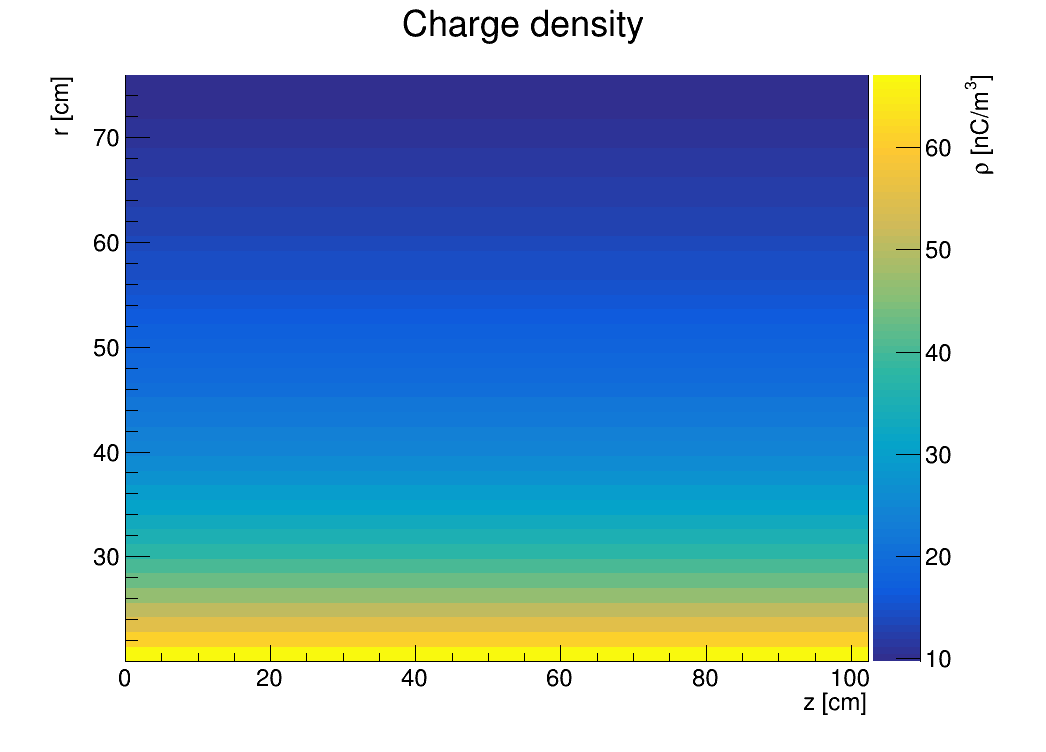

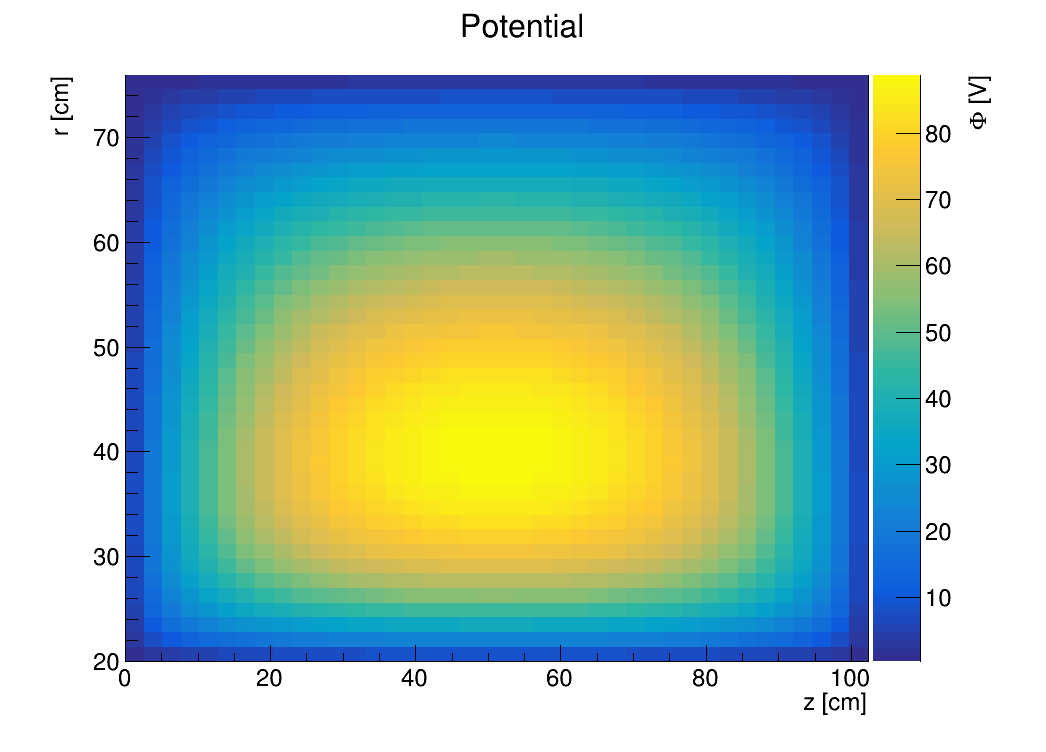

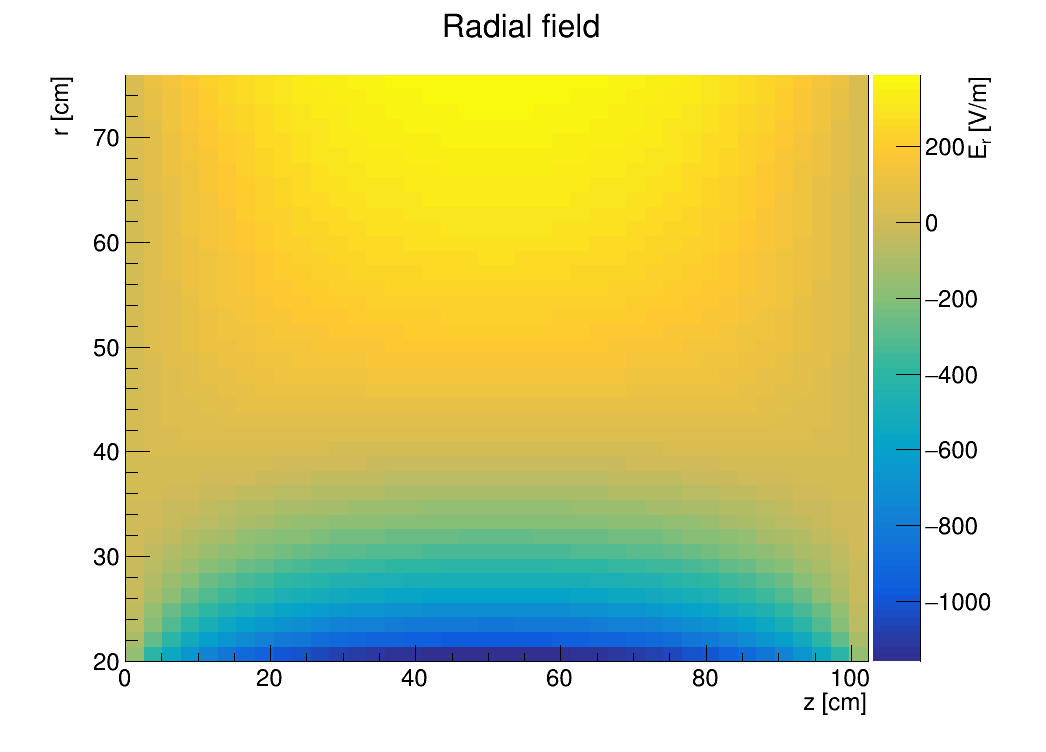

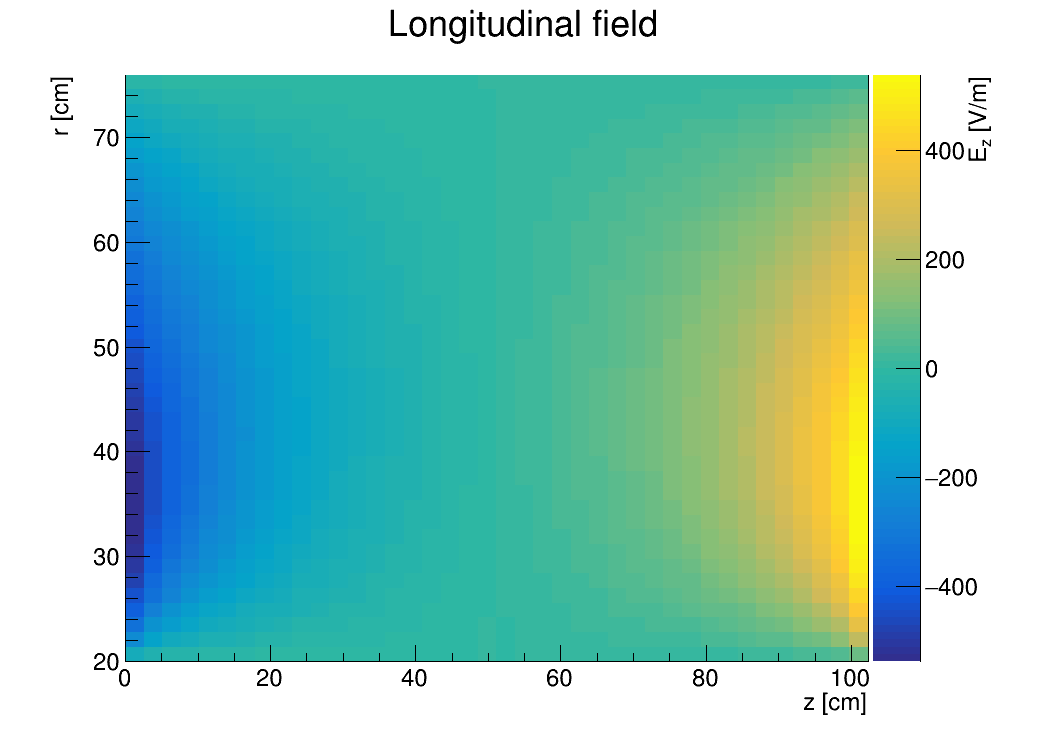

Info in <TCanvas::Print>: png file direct_green_qa/qa_rho.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Phi.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Er.png has been created
Info in <TCanvas::Print>: png file direct_green_qa/qa_Ez.png has been created


In [ ]:
if DO_QA:
    for stem, arr, title, ztitle in [
        ("rho", np.mean(rho, axis=1)*1e9, "Charge density", "#rho [nC/m^{3}]"),
        ("Phi", np.mean(Phi, axis=1), "Potential", "#Phi [V]"),
        ("Er", np.mean(Er, axis=1), "Radial field", "E_{r} [V/m]"),
        ("Ez", np.mean(Ez, axis=1), "Longitudinal field", "E_{z} [V/m]")
    ]:
        if stem == "rho":
            x_edges = z_src_edges * M_TO_CM
            y_edges = r_src_edges * M_TO_CM
        else:
            x_edges = z_obs_edges * M_TO_CM
            y_edges = r_obs_edges * M_TO_CM

        draw(
            "qa_" + stem,
            make_th2(
                "hqa" + stem,
                title,
                arr.T,
                x_edges,
                y_edges,
                "z [cm]",
                "r [cm]",
                ztitle
            )
        )


## 8.2 What proves that this is a cylindrical calculation

The following features are enforced before output is written:

1. The radial domain is the annulus \(a<r<b\).
2. Source-cell volumes use the cylindrical Jacobian
   \(r\,dr\,d\phi\,dz\) exactly.
3. The \(\phi\) grid covers one complete period \(0\leq\phi<2\pi\).
4. Every angular separation is evaluated with
   `wrapped_delta_phi`.
5. Every angular basis function is an integer Fourier harmonic.
6. Pointwise kernels are invariant under independent
   \(\phi\rightarrow\phi+2\pi\) shifts of observation and source.
7. Equivalent point pairs across and away from the seam give identical
   kernels.
8. The convolved fields are checked for ordinary last-to-first adjacent-bin
   behavior.
9. An axisymmetric source is required to produce vanishing \(E_\phi\) and no
   \(\phi\)-dependent part of \(E_r\) or \(E_z\), within numerical precision.

These tests are performed on the same functions and arrays used in the direct
convolution; they are not corrections applied only during plotting.


## 9. Output files

The notebook writes three ROOT files.

### Green kernels

```text
sphenix_direct_green_kernels.root
```

The `GreenKernels` tree contains all sampled source-observation pairs and the values of $G$, $K_r$, $K_\phi$, and $K_z$.

### Three-dimensional fields

```text
sphenix_direct_fields_3d.root
```

It contains `hRho`, `hPhi`, `hEr`, `hEphi`, and `hEz`.

### PHGarfield-compatible maps

```text
sphenix_direct_garfield_field.root
```

It contains

```text
QA/hErDefault
QA/hEzDefault
```

with field values in $\mathrm{V/m}$ and axes in centimeters.

In [ ]:
# Green kernel TTree
f=root.TFile(GREEN_FILE,"RECREATE")
t=root.TTree("GreenKernels","Direct sampled Green kernels")
idx={n:array("i",[0]) for n in ["iro","ipo","izo","irs","ips","izs"]}
val={n:array("d",[0.]) for n in ["ro","po","zo","rs","ps","zs","G","Kr","Kp","Kz"]}
for n,a0 in idx.items(): t.Branch(n,a0,f"{n}/I")
for n,a0 in val.items(): t.Branch(n,a0,f"{n}/D")
for iro,ro in enumerate(r_obs):
 for ipo,po in enumerate(phi_obs):
  for izo,zo in enumerate(z_obs):
   for irs,rsv in enumerate(r_src):
    for ips,ps in enumerate(phi_src):
     for izs,zs in enumerate(z_src):
      for n,v in zip(idx,[iro,ipo,izo,irs,ips,izs]): idx[n][0]=v
      for n,v in zip(["ro","po","zo","rs","ps","zs"],[ro,po,zo,rsv,ps,zs]): val[n][0]=v
      q=(iro,ipo,izo,irs,ips,izs)
      for n,v in zip(["G","Kr","Kp","Kz"],[G[q],Kr[q],Kp[q],Kz[q]]): val[n][0]=v
      t.Fill()
t.Write()
root.TNamed("metadata_json",json.dumps({"shape":list(G.shape),"used_for_fields":True},indent=2)).Write()
f.Close()

In [ ]:
def th3(name,title,v,xe,ye,ze):
    h=root.TH3D(name,title,len(xe)-1,np.asarray(xe,dtype="d"),len(ye)-1,np.asarray(ye,dtype="d"),len(ze)-1,np.asarray(ze,dtype="d"))
    for i in range(v.shape[0]):
        for j in range(v.shape[1]):
            for k in range(v.shape[2]): h.SetBinContent(i+1,j+1,k+1,float(v[i,j,k]))
    return h

f=root.TFile(FIELD_FILE,"RECREATE")
for h in [
    th3("hRho","rho",rho,r_src_edges*M_TO_CM,phi_src_edges,z_src_edges*M_TO_CM),
    th3("hPhi","Phi",Phi,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEr","Er",Er,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEphi","Ephi",Ephi,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    th3("hEz","Ez",Ez,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM)
]: h.Write()
f.Close()

f=root.TFile(GARFIELD_FILE,"RECREATE"); d=f.mkdir("QA"); d.cd()
make_th2("hErDefault","Er for PHGarfield",np.mean(Er,axis=1),r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{r} [V/m]").Write()
make_th2("hEzDefault","Ez for PHGarfield",np.mean(Ez,axis=1),r_obs_edges*M_TO_CM,z_obs_edges*M_TO_CM,"r [cm]","|z| [cm]","E_{z} [V/m]").Write()
f.Close()
print(GREEN_FILE,FIELD_FILE,GARFIELD_FILE)

sphenix_direct_green_kernels.root sphenix_direct_fields_3d.root sphenix_direct_garfield_field.root


saving 2d root histoss in the file

In [ ]:
if True:
    hitsts_to_save = []
    outfile = root.TFile("output/spacechargeEfields.root","RECREATE")

    for stem, arr, title, ztitle in [
        ("rho", np.mean(rho, axis=1)*1e9, "Charge density", "#rho [nC/m^{3}]"),
        ("Phi", np.mean(Phi, axis=1), "Potential", "#Phi [V]"),
        ("Er", np.mean(Er, axis=1), "Radial field", "E_{r} [V/m]"),
        ("Ez", np.mean(Ez, axis=1), "Longitudinal field", "E_{z} [V/m]")
    ]:
        if stem == "rho":
            x_edges = z_src_edges * M_TO_CM
            y_edges = r_src_edges * M_TO_CM
        else:
            x_edges = z_obs_edges * M_TO_CM
            y_edges = r_obs_edges * M_TO_CM

        hitsts_to_save.append(make_th2(
                "hqa" + stem,
                title,
                arr.T,
                x_edges,
                y_edges,
                "z [cm]",
                "r [cm]",
                ztitle))
        hitsts_to_save[-1].SetDirectory(outfile)
        hitsts_to_save[-1].Write()
    outfile.Close()